# Data Ingestion and Structural Validation
**Purpose:** Read the CSV data. Let's load it up! What do I got?
(c) Drandreb Earl Juanico

In [24]:
# First, install required packages to make this notebook self-contained
!pip -q install numpy
!pip -q install matplotlib
!pip -q install pandas
!pip -q install seaborn
!pip -q install geopandas
!pip -q install shapely
!pip -q install networkx

# Load and inspect main.csv, ports.csv, and importer_normalized_data.csv files
import pandas as pd
# Load the CSV files into DataFrames
main_df = pd.read_csv('main.csv')
ports_df = pd.read_csv('ports.csv')
importer_df = pd.read_csv('importer_normalized_data.csv')
# Display the first few rows of each DataFrame to inspect the data
print("Main DataFrame:")
print(main_df.head())
print("\nPorts DataFrame:")
print(ports_df.head())
print("\nImporter Normalized DataFrame:")
print(importer_df.head())
# Display the column names of each DataFrame to understand their structure
print("\nMain DataFrame Columns:")
print(main_df.columns)
print("\nPorts DataFrame Columns:")
print(ports_df.columns)
print("\nImporter Normalized DataFrame Columns:")
print(importer_df.columns)

# Row counts per file
print("\nRow counts:")
print(f"Main DataFrame: {len(main_df)} rows")
print(f"Ports DataFrame: {len(ports_df)} rows")
print(f"Importer Normalized DataFrame: {len(importer_df)} rows")

# Column data types vs expected schema
print("\nData Types:")
print("Main DataFrame Data Types:")
print(main_df.dtypes)
print("\nPorts DataFrame Data Types:")
print(ports_df.dtypes)
print("\nImporter Normalized DataFrame Data Types:")
print(importer_df.dtypes)

# Missing values per field
print("\nMissing Values:")
print("Main DataFrame Missing Values:")
print(main_df.isnull().sum())
print("\nPorts DataFrame Missing Values:")
print(ports_df.isnull().sum())
print("\nImporter Normalized DataFrame Missing Values:")
print(importer_df.isnull().sum())

# Duplicate rows (especially shipment-level duplicates)
print("\nDuplicate Rows:")
print(f"Main DataFrame Duplicate Rows: {main_df.duplicated().sum()}")
print(f"Ports DataFrame Duplicate Rows: {ports_df.duplicated().sum()}")
print(f"Importer Normalized DataFrame Duplicate Rows: {importer_df.duplicated().sum()}")

# Create a quality summary table (missing %, duplicates, anomalies)
def quality_summary(df, name):
    total_rows = len(df)
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / total_rows) * 100
    duplicate_rows = df.duplicated().sum()
    
    summary = pd.DataFrame({
        'Field': df.columns,
        'Missing Values': missing_values,
        'Missing Percentage': missing_percentage
    })
    
    print(f"\nQuality Summary for {name}:")
    print(summary)
    print(f"Total Duplicate Rows in {name}: {duplicate_rows}")
quality_summary(main_df, "Main DataFrame")
quality_summary(ports_df, "Ports DataFrame")
quality_summary(importer_df, "Importer Normalized DataFrame")
# --- END IGNORE ---
                                                       


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Main DataFrame:
   Unnamed: 0                                          consignee  \
0           0  {name=PIOTR KURPINOWICZ, address=26 OLD WELL R...   
1           1  {name=TRANSOM SYMPHONY OPCO LLC, address=120 L...   
2  

# Data Preparation for Exploratory Analysis
What am I dealing with?

In [25]:
import ast
import re
import json
# Parse Consignee (dict object) -> extract:
#  name
#  address
def parse_consignee(consignee_str):
    if pd.isna(consignee_str):
        return pd.Series([None, None])

    # If already a dict
    if isinstance(consignee_str, dict):
        return pd.Series([consignee_str.get("name"), consignee_str.get("address")])

    text = str(consignee_str)

    # Try JSON first
    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return pd.Series([obj.get("name"), obj.get("address")])
    except Exception:
        pass

    # Handle "{name=..., address=...}" format
    name_match = re.search(r"name=([^,}]+)", text)
    addr_match = re.search(r"address=([^}]+)", text)
    name = name_match.group(1).strip() if name_match else None
    address = addr_match.group(1).strip() if addr_match else None
    return pd.Series([name, address])

def normalize_name(s):
    if pd.isna(s):
        return None
    s = str(s).upper().strip()
    s = re.sub(r"[^A-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Heuristic: keep commercial entities, drop obvious individuals/non-business
BUSINESS_KEYWORDS = r"\b(CORP|CORPORATION|INC|LLC|LTD|CO|COMPANY|GMBH|S\.A\.|SAS|BV|AG|PTY|LP|LLP)\b"
def is_commercial(name):
    if pd.isna(name):
        return False
    n = normalize_name(name)
    if not n:
        return False
    # likely individual if contains common honorifics and no business keyword
    individual_markers = r"\b(MR|MRS|MS|MISS|DR|PROF)\b"
    if re.search(individual_markers, n) and not re.search(BUSINESS_KEYWORDS, n):
        return False
    return True

# Join with Company Normalized:
#  Map raw names -> deduped company entities
#  Retain only Top 10k ranked importers
def join_with_normalized(df, importer_df):
    df = df.copy()
    importer_df = importer_df.copy()

    df["consignee_name_norm"] = df["Consignee Company Name"].apply(normalize_name)
    importer_df["importer_raw_name_norm"] = importer_df["importer_raw_name"].apply(normalize_name)

    merged_df = df.merge(
        importer_df[["importer_rank", "importer_raw_name", "importer_raw_name_norm", "importer_deduped_name"]],
        left_on="consignee_name_norm",
        right_on="importer_raw_name_norm",
        how="left"
    )

    merged_df["is_top_10k_importer"] = merged_df["importer_rank"].le(10000)
    return merged_df

# Provide clean Company-level Import Table
def create_clean_import_table(main_df, importer_df):
    parsed_names = main_df["consignee"].apply(parse_consignee)
    main_df["Consignee Company Name"] = parsed_names[0]
    main_df["Consignee Address"] = parsed_names[1]

    filtered_df = main_df[main_df["Consignee Company Name"].apply(is_commercial)]

    clean_import_table = join_with_normalized(filtered_df, importer_df)

    # Merge ports_df without using join_with_normalized
    clean_import_table = clean_import_table.merge(
        ports_df[["port_code", "port_name"]].drop_duplicates(),
        left_on="port_of_unlading",
        right_on="port_code",
        how="left",
        suffixes=("", "_ports"),
        indicator=True,
    )

    # Validation: ensure every row has a matching port_name/port_code
    missing_ports = clean_import_table["_merge"].ne("both").sum()
    print(f"Rows without matching port in ports_df: {missing_ports}")
    if missing_ports:
        print(clean_import_table.loc[clean_import_table["_merge"].ne('both'), "port_of_unlading"].value_counts().head(10))

    clean_import_table = clean_import_table.drop(columns=["_merge"])

    result_df = clean_import_table[[
        "Consignee Company Name",
        "Consignee Address",
        "file_month",
        "calculated_teu",
        "country_of_origin",
        "port_of_unlading",
        "port_code",
        "port_name",
        "hs_codes",
        "importer_rank",
        "importer_deduped_name",
        "is_top_10k_importer"
    ]].drop_duplicates()

    return result_df

# Create the clean Company-level Import Table
clean_import_table = create_clean_import_table(main_df, importer_df)
print("\nClean Company-level Import Table:")
print(clean_import_table.head())
# --- IGNORE ---


Rows without matching port in ports_df: 0

Clean Company-level Import Table:
      Consignee Company Name  \
0          PIOTR KURPINOWICZ   
1  TRANSOM SYMPHONY OPCO LLC   
2               VARITILE INC   
3           BSN MEDICAL GMBH   
4   TRANSGROUP INTERNATIONAL   

                                   Consignee Address  file_month  \
0  26 OLD WELL RD. USA INLAND LOCATION 06907 US, ...           1   
1  120 LONG RIDGE RD, 3FL STAMFORD 06902 US, clea...           1   
2  1930 NORTH GREAT SOUTHWEST PARKWAY 75050 GRAND...           1   
3  400 OLMOS BLVD STE A HIDALGO TX 78557 US, clea...           1   
4  860 DEVON AVENUE BENSENVILLE IL 60106 UNITED S...           1   

   calculated_teu country_of_origin  port_of_unlading  port_code  \
0        0.849421            POLAND              4601       4601   
1        1.000000             ITALY              1401       1401   
2        2.000000           BELGIUM              5301       5301   
3        0.035356           GERMANY              

In [26]:
# Sanity check: print top 10 rows where is_top_10k_importer is True
print(clean_import_table[clean_import_table["is_top_10k_importer"]==True].head(10))


                Consignee Company Name  \
3                     BSN MEDICAL GMBH   
11                           ZGEAR LLC   
13            WILLIAM H. KOPKE JR. INC   
20                 IQI WAREHOUSING USA   
26                   ROBERT BOSCH GMBH   
36  DIRECTBUY HOME IMPROVEMENT INC D B   
54                   FEVERTREE USA INC   
67                          THULE INC.   
75         KURZ TRANSFER PRODUCTS L.P.   
84          WJ DEUTSCH - BLUE DIVISION   

                                    Consignee Address  file_month  \
3   400 OLMOS BLVD STE A HIDALGO TX 78557 US, clea...           1   
11  1816 S JACKSON MAGNOLIA AR 71753 US, cleaned_a...           1   
13  1000 NORTHERN BLVD SUITE 200 GREAT NECK NY 110...           1   
20  400 GANDY DANCER DR TRACY CA 95377 US, cleaned...           1   
26  BIETIGHEIMER STR. 50 TAMM DE, cleaned_address=...           1   
36  8450 BROADWAY, MERRILLVILLE, IN 46410 MERRILLV...           1   
54  THE PENTHOUSE 37 WEST 26TH STREET NEW YORK NY ... 

# TEU Standardization
Convert Calculated TEU from string → numeric

Handle:

* Nulls
* Zero-TEU records
* Extreme outliers (winsorize or flag)

Why this matters:

TEU becomes the core proxy for import volume and economic scale

In [27]:
# Convert calculated TEU from string to numeric
# Handle:
#   nulls, zero-TEU records, extreme outliers (winsorize or flag)
def convert_teu(teu_str):
    try:
        teu = float(teu_str)
        if teu < 0:
            return None
        return teu
    except (ValueError, TypeError):
        return None

clean_import_table["calculated_teu_numeric"] = clean_import_table["calculated_teu"].apply(convert_teu)

In [28]:
# Sanity check: print top 10 rows where is_top_10k_importer is True
print(clean_import_table[clean_import_table["is_top_10k_importer"]==True].head(10))


                Consignee Company Name  \
3                     BSN MEDICAL GMBH   
11                           ZGEAR LLC   
13            WILLIAM H. KOPKE JR. INC   
20                 IQI WAREHOUSING USA   
26                   ROBERT BOSCH GMBH   
36  DIRECTBUY HOME IMPROVEMENT INC D B   
54                   FEVERTREE USA INC   
67                          THULE INC.   
75         KURZ TRANSFER PRODUCTS L.P.   
84          WJ DEUTSCH - BLUE DIVISION   

                                    Consignee Address  file_month  \
3   400 OLMOS BLVD STE A HIDALGO TX 78557 US, clea...           1   
11  1816 S JACKSON MAGNOLIA AR 71753 US, cleaned_a...           1   
13  1000 NORTHERN BLVD SUITE 200 GREAT NECK NY 110...           1   
20  400 GANDY DANCER DR TRACY CA 95377 US, cleaned...           1   
26  BIETIGHEIMER STR. 50 TAMM DE, cleaned_address=...           1   
36  8450 BROADWAY, MERRILLVILLE, IN 46410 MERRILLV...           1   
54  THE PENTHOUSE 37 WEST 26TH STREET NEW YORK NY ... 

# Univariate Analysis (Foundational Understanding)

Purpose: Understand distributions and scale.

### Import Volume

* Distribution of TEU:
    * Overall
    * Per company
    * Per country
    * Per port
* Identify:
    * Heavy-tailed behavior
    * Top 1%, 5%, 10% contributors

### Temporal Trends
* Monthly TEU trends (2021)
* Seasonality detection
* Month-over-month volatility

### Deliverables:
* TEU distribution plots
* Monthly trend charts

In [29]:
# Extract the distribution of TEU: overall, per copmany, per country, per port
def teu_distribution(df, group_by_field=None):
    if group_by_field:
        distribution = df.groupby(group_by_field)["calculated_teu_numeric"].describe()
    else:
        distribution = df["calculated_teu_numeric"].describe()
    return distribution

# Get overall TEU distribution
overall_teu_dist = teu_distribution(clean_import_table)
print("\nOverall TEU Distribution:")
print(overall_teu_dist)
# Get TEU distribution per company
teu_dist_per_company = teu_distribution(clean_import_table, group_by_field="importer_deduped_name")
print("\nTEU Distribution per Company:")
print(teu_dist_per_company.head())
# Get TEU distribution per country of origin
teu_dist_per_country = teu_distribution(clean_import_table, group_by_field="country_of_origin")
print("\nTEU Distribution per Country of Origin:")
print(teu_dist_per_country.head())
# Get TEU distribution per port of entry
teu_dist_per_port = teu_distribution(clean_import_table, group_by_field="port_of_unlading")
print("\nTEU Distribution per Port of Entry:")
print(teu_dist_per_port.head())

# Identify heavy-tailed behavior and outliers in TEU distribution
import numpy as np
teu_values = clean_import_table["calculated_teu_numeric"].dropna()
q1 = np.percentile(teu_values, 25)
q3 = np.percentile(teu_values, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = clean_import_table[
    (clean_import_table["calculated_teu_numeric"] < lower_bound) |
    (clean_import_table["calculated_teu_numeric"] > upper_bound)
]
print(f"\nIdentified {len(outliers)} outlier records based on TEU distribution:")
print(outliers[["Consignee Company Name", "calculated_teu_numeric"]].head(10))

# Top 1%, 5%, 10% contributors to total TEU volume
total_teu = teu_values.sum()
teu_sorted = teu_values.sort_values(ascending=False).reset_index(drop=True)
cumulative_teu = teu_sorted.cumsum()
top_1pct_threshold = total_teu * 0.01
top_5pct_threshold = total_teu * 0.05
top_10pct_threshold = total_teu * 0.10

# Temporal trends: monthly TEU trends, seasonality detection, month-over-month volatility
# main dataframe only has a file_month field, which is an integer representing month. Year is 2021
import calendar
clean_import_table["file_month"] = clean_import_table["file_month"].astype(int)
clean_import_table["file_month_label"] = clean_import_table["file_month"].apply(
    lambda m: f"{calendar.month_abbr[m]}21"
)
monthly_teu_trends = clean_import_table.groupby("file_month")["calculated_teu_numeric"].sum()
print("\nMonthly TEU Trends:")
print(monthly_teu_trends)   
# --- END IGNORE ---


Overall TEU Distribution:
count    2.079950e+06
mean     2.588466e+00
std      7.085670e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      2.000000e+00
max      1.000000e+03
Name: calculated_teu_numeric, dtype: float64

TEU Distribution per Company:
                                                    count       mean  \
importer_deduped_name                                                  
(ZEN-NOH) NATIONAL FEDERATION OF AGRICULTURAL C...   19.0  12.631579   
1-800-FLOWERS.COM INC                                11.0   4.181818   
1027 WILSHIRE JV LLC                                 25.0   3.552763   
14 KARAT HOME INC                                     3.0   2.666667   
18946 HWY 37 SOUTH                                    1.0   2.000000   

                                                         std       min  25%  \
importer_deduped_name                                                         
(ZEN-NOH) NATIONAL FEDERATION OF AGRICULTURAL C...  6.6610

In [30]:
# keys of clean_import_table
print("\nKeys of clean_import_table:")
print(clean_import_table.columns)


Keys of clean_import_table:
Index(['Consignee Company Name', 'Consignee Address', 'file_month',
       'calculated_teu', 'country_of_origin', 'port_of_unlading', 'port_code',
       'port_name', 'hs_codes', 'importer_rank', 'importer_deduped_name',
       'is_top_10k_importer', 'calculated_teu_numeric', 'file_month_label'],
      dtype='object')


In [31]:
# view unique file_month values in main dataframe
unique_file_months = main_df["file_month"].unique()
print("\nUnique file_month values in main DataFrame:")
print(unique_file_months)


Unique file_month values in main DataFrame:
[ 1  9  5  6  7  3  8 12 10 11  2  4]


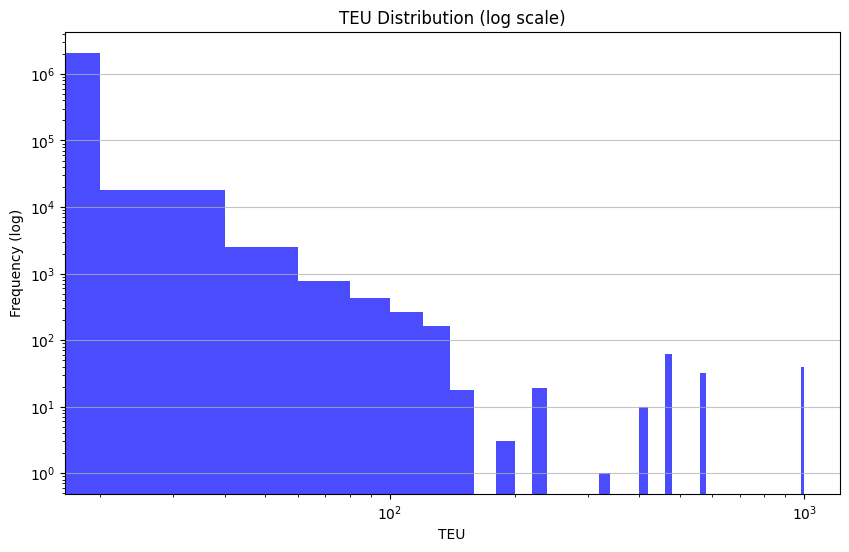

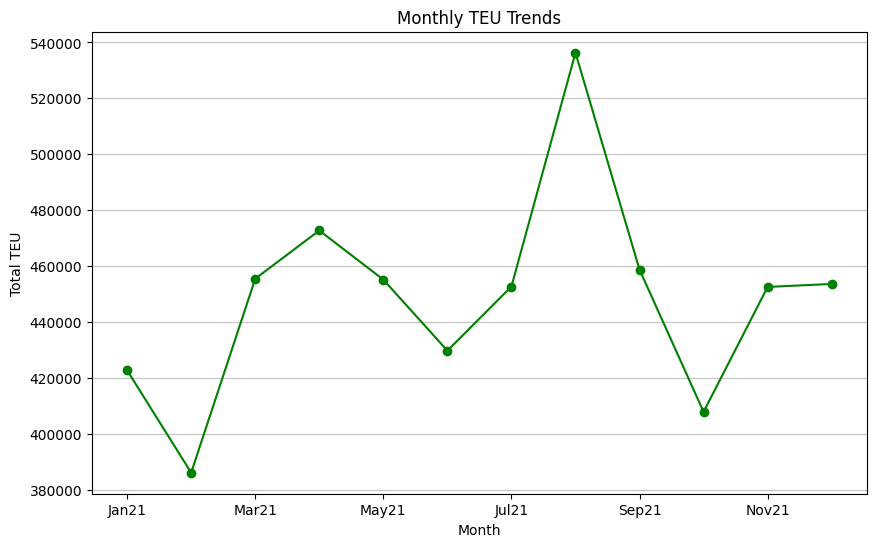

In [32]:
# Provide TEU distribution plot and monthly trend charts
# --- IGNORE ---
import matplotlib.pyplot as plt

# TEU Distribution Plot (log y-axis)
plt.figure(figsize=(10, 6))
plt.hist(clean_import_table["calculated_teu_numeric"].dropna(), bins=50, color="blue", alpha=0.7)
plt.yscale("log") # logarithmic y-axis
plt.xscale("log") # logarithmic x-axis
plt.title("TEU Distribution (log scale)")
plt.xlabel("TEU")
plt.ylabel("Frequency (log)")
plt.grid(axis="y", alpha=0.75)
plt.show()

# Monthly TEU Trend Chart (ordered by month)
monthly_teu_trends = (
    clean_import_table.groupby("file_month")["calculated_teu_numeric"].sum().sort_index()
)
monthly_teu_trends.index = monthly_teu_trends.index.map(lambda m: f"{calendar.month_abbr[m]}21")

plt.figure(figsize=(10, 6))
monthly_teu_trends.plot(kind="line", marker="o", color="green")
plt.title("Monthly TEU Trends")
plt.xlabel("Month")
plt.ylabel("Total TEU")
plt.grid(axis="y", alpha=0.75)
plt.show()
# --- END IGNORE ---

### Import Volume Analysis

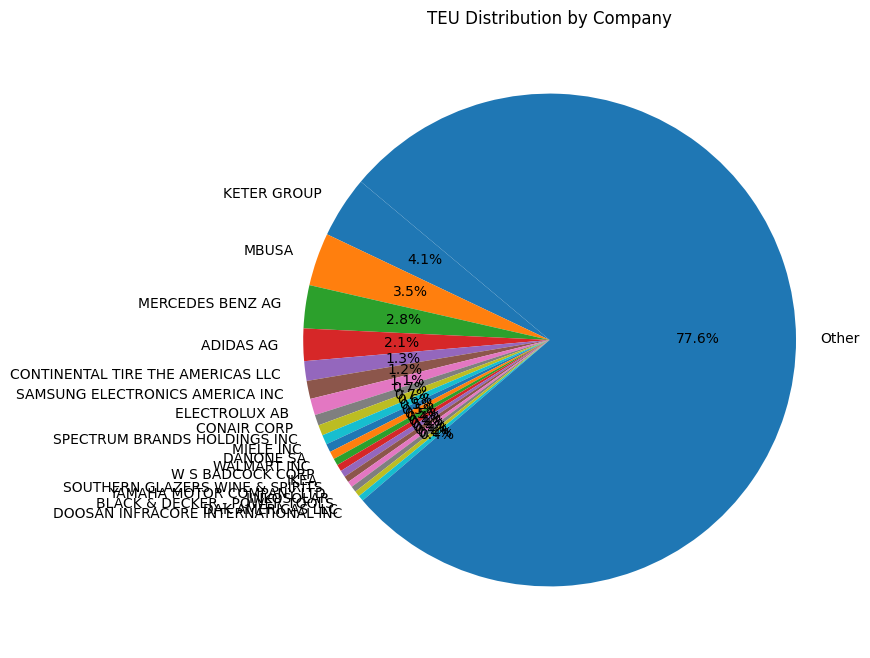

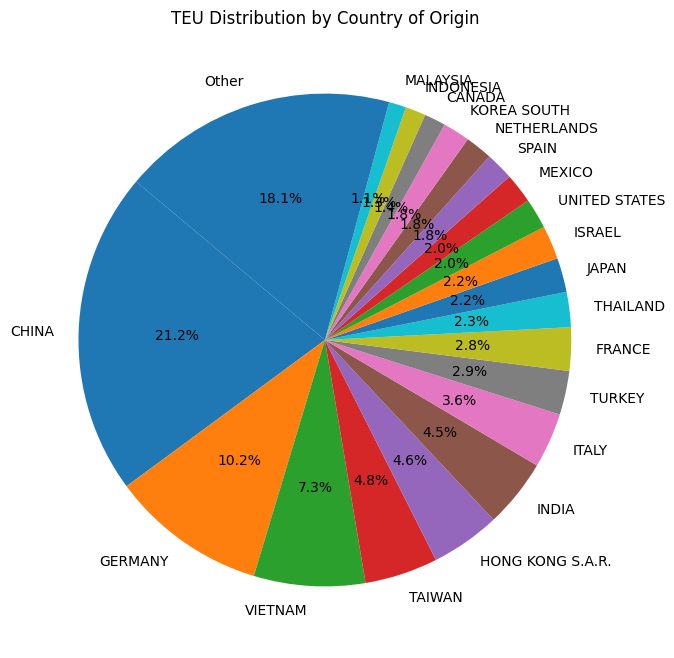

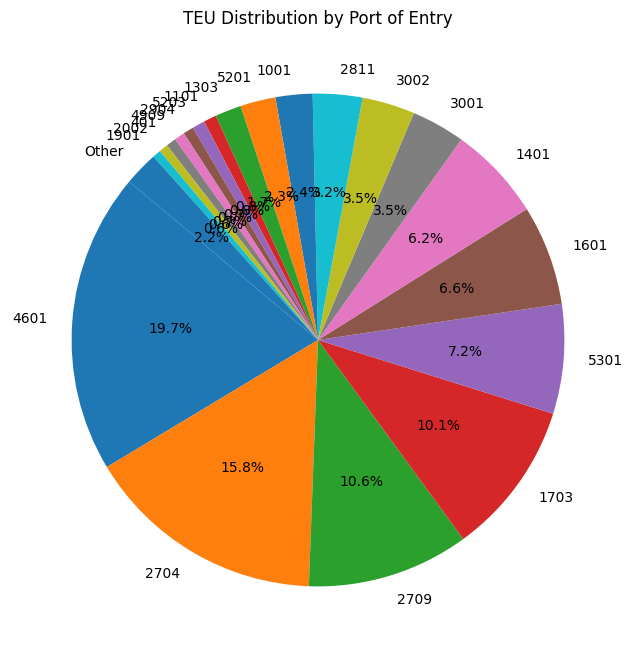

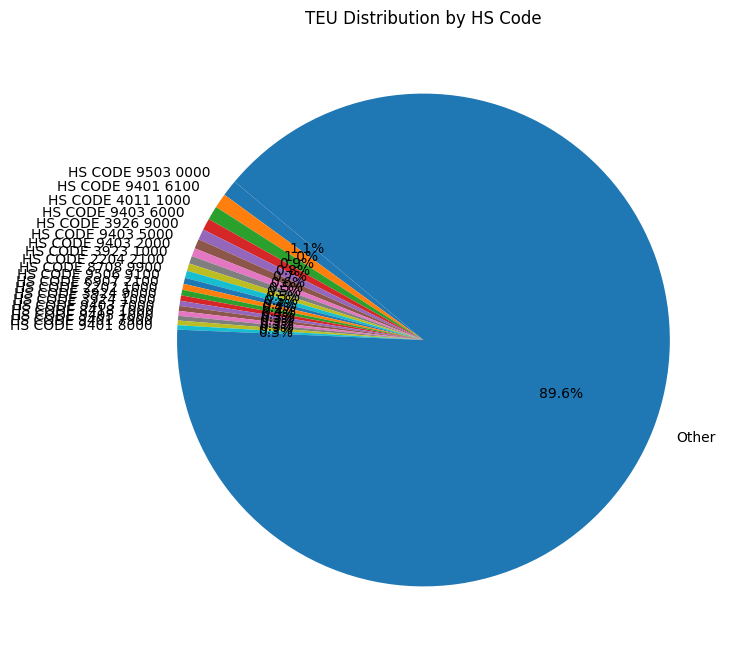

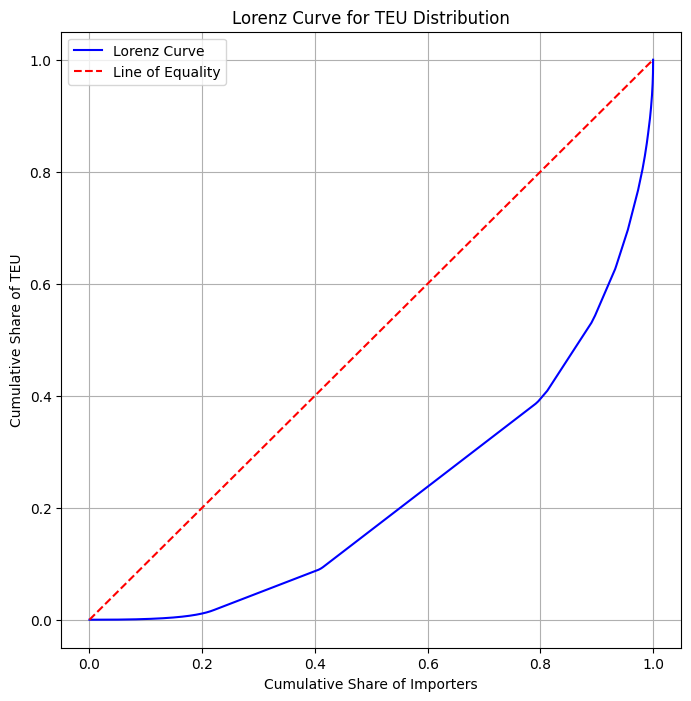


Gini Coefficient for TEU Distribution: 0.5565


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/2227966326.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini_coefficient = 1 - 2 * np.trapz(cumulative_teu, x)


In [33]:
# Multiple juxtaposed pie charts showing distribution of TEU by: company, country, port
# --- IGNORE ---
def plot_pie_chart(data, title, top_n=10):
    top_data = data.sort_values(ascending=False).head(top_n)
    other_data = data.sum() - top_data.sum()
    pie_data = pd.concat([top_data, pd.Series({"Other": other_data})])

    plt.figure(figsize=(8, 8))
    pie_data.plot(kind="pie", autopct="%1.1f%%", startangle=140)
    plt.title(title)
    plt.ylabel("")
    plt.show()
# --- END IGNORE ---
# Identify heavy-tailed behavior and outliers in TEU distribution: analyzing top 1%, 5%, 10% contributors to total TEU volume
# --- IGNORE ---
def plot_top_contributors(teu_values, total_teu, percentiles=[1, 5, 10]):
    teu_sorted = teu_values.sort_values(ascending=False).reset_index(drop=True)
    cumulative_teu = teu_sorted.cumsum()

    for pct in percentiles:
        threshold = total_teu * (pct / 100)
        num_contributors = (cumulative_teu <= threshold).sum()
        print(f"Top {pct}% contributors account for {threshold} TEU with {num_contributors} contributors.")
# --- END IGNORE ---

#  Per company
plot_pie_chart(
    clean_import_table.groupby("importer_deduped_name")["calculated_teu_numeric"].sum(),
    "TEU Distribution by Company",top_n=20
)
#  Per country of origin
plot_pie_chart(
    clean_import_table.groupby("country_of_origin")["calculated_teu_numeric"].sum(),
    "TEU Distribution by Country of Origin",top_n=20
)
#  Per port of entry
plot_pie_chart(
    clean_import_table.groupby("port_of_unlading")["calculated_teu_numeric"].sum(),
    "TEU Distribution by Port of Entry",top_n=20
)
#  Per HS code (top 20)
import itertools
def explode_labels(labels, max_len=15):
    new_labels = []
    for label in labels:
        if len(label) > max_len:
            # Split label into chunks of max_len
            chunks = [label[i:i+max_len] for i in range(0, len(label), max_len)]
            new_labels.append("\n".join(chunks))
        else:
            new_labels.append(label)
    return new_labels
hs_code_teu = clean_import_table.explode("hs_codes").groupby("hs_codes")["calculated_teu_numeric"].sum()
plot_pie_chart(
    hs_code_teu,
    "TEU Distribution by HS Code",top_n=20
)

# Plot Lorenz curve for TEU distribution and calculate Gini coefficient
# Show the inequality in TEU distribution among importers
# --- IGNORE ---
def plot_lorenz_curve(teu_values):
    sorted_teu = np.sort(teu_values)
    cumulative_teu = np.cumsum(sorted_teu)
    cumulative_teu = np.insert(cumulative_teu, 0, 0)
    cumulative_teu /= cumulative_teu[-1]

    n = len(teu_values)
    x = np.linspace(0, 1, n + 1)

    plt.figure(figsize=(8, 8))
    plt.plot(x, cumulative_teu, label="Lorenz Curve", color="blue")
    plt.plot([0, 1], [0, 1], label="Line of Equality", color="red", linestyle="--")
    plt.title("Lorenz Curve for TEU Distribution")
    plt.xlabel("Cumulative Share of Importers")
    plt.ylabel("Cumulative Share of TEU")
    plt.legend()
    plt.grid()
    plt.show()

    # Calculate Gini coefficient
    gini_coefficient = 1 - 2 * np.trapz(cumulative_teu, x)
    return gini_coefficient
# --- END IGNORE ---    
gini_coeff = plot_lorenz_curve(clean_import_table["calculated_teu_numeric"].dropna())
print(f"\nGini Coefficient for TEU Distribution: {gini_coeff:.4f}") 


### Notes for Interpretation
* **High Inequality / Heavy-Tailed Distribution:** If the distribution is *heavy-tailed* (e.g., top 1% hold a massive share), the Lorenz curve will be highly concave (bowed). The curve will stay very close to the horizontal axis for most of the population, only rising sharply near the 100th percentile, reflecting that a small number of households possess the vast majority of resources.
* **Gini Coefficient and Tails:** The *Gini coefficient*, derived from the area between the curve and the 45-degree line, approaches 1 (or 100%) in these cases. A more concave, "pushed-down" curve indicates higher inequality and a thicker tail of the distribution.
* **Upper Tail Dominance:** The slope of the Lorenz curve is the cumulative income share. For heavy-tailed distributions, the slope is very flat at the beginning (low-income tail) and becomes extremely steep near the top (high-income tail), representing a large concentration of wealth.

## Country and Supply-Chain Dependency Analysis
**Purpose:** Reveal geopolitical and sourcing risk

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/887362225.py:13: RuntimeWarning: invalid value encountered in scalar divide
  if top_country_teu / total_teu >= 0.5:



Companies with >=50% imports from a single country:
(ZEN-NOH) NATIONAL FEDERATION OF AGRICULTURAL COOPERATIVE ASSOCIATIONS: CANADA (100.00%)
1-800-FLOWERS.COM INC: HONG KONG S.A.R. (58.70%)
1027 WILSHIRE JV LLC: TURKEY (85.57%)
14 KARAT HOME INC: CHINA (100.00%)
18946 HWY 37 SOUTH: CHINA (100.00%)
1ST IMPORT USA: TAIWAN (100.00%)
247 TIRE SERVICE: CHINA (100.00%)
2583319 ONTARIO INC: INDONESIA (100.00%)
26 INTERNATIONAL INC: CHINA (100.00%)
39F INC: CHINA (50.00%)
3M HUTCHINSON: FRANCE (98.16%)
4PATRIOTS LLC: CHINA (100.00%)
5 STAR APPAREL LLC: BANGLADESH (90.94%)
5.11 TACTICAL: VIETNAM (100.00%)
7450773 TRADING INC: VIETNAM (100.00%)
8 VINI INC: ITALY (100.00%)
84 LUMBER COMPANY: BRAZIL (100.00%)
9 TO 5 SEATING: CHINA (100.00%)
A & B INGREDIENTS INC: BELGIUM (85.71%)
A & M PRODUCTS MANUFACTURING COMPAN: CHINA (100.00%)
A CLASS SUPPLY INC: HONG KONG S.A.R. (100.00%)
A J MANUFACTURING INC: TAIWAN (100.00%)
A L DIAMOND HOME PRODUCTS LLC: CHINA (100.00%)
A PLUS INTERNATIONAL INC: CAMBODI

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/887362225.py:24: RuntimeWarning: invalid value encountered in scalar divide
  if top2_countries_teu / total_teu >= 0.7:



Companies with >=70% imports from top 2 countries:
(ZEN-NOH) NATIONAL FEDERATION OF AGRICULTURAL COOPERATIVE ASSOCIATIONS: (100.00%)
1-800-FLOWERS.COM INC: (80.43%)
1027 WILSHIRE JV LLC: (100.00%)
14 KARAT HOME INC: (100.00%)
18946 HWY 37 SOUTH: (100.00%)
1ST IMPORT USA: (100.00%)
247 TIRE SERVICE: (100.00%)
2583319 ONTARIO INC: (100.00%)
26 INTERNATIONAL INC: (100.00%)
2NDS IN BUILDING MATERIALS INC: (75.07%)
39F INC: (100.00%)
3M HUTCHINSON: (99.85%)
47 BRAND LLC: (74.68%)
4PATRIOTS LLC: (100.00%)
5 STAR APPAREL LLC: (99.79%)
5.11 INC: (71.12%)
5.11 TACTICAL: (100.00%)
7450773 TRADING INC: (100.00%)
8 VINI INC: (100.00%)
84 LUMBER COMPANY: (100.00%)
9 TO 5 SEATING: (100.00%)
A & B INGREDIENTS INC: (100.00%)
A & M PRODUCTS MANUFACTURING COMPAN: (100.00%)
A CLASS SUPPLY INC: (100.00%)
A J MANUFACTURING INC: (100.00%)
A L DIAMOND HOME PRODUCTS LLC: (100.00%)
A PLUS INTERNATIONAL INC: (100.00%)
A SAFE INC: (100.00%)
A&B TROPICAL PRODUCE LLC: (100.00%)
A&E INTERNATIONAL INC: (100.00%)
A&

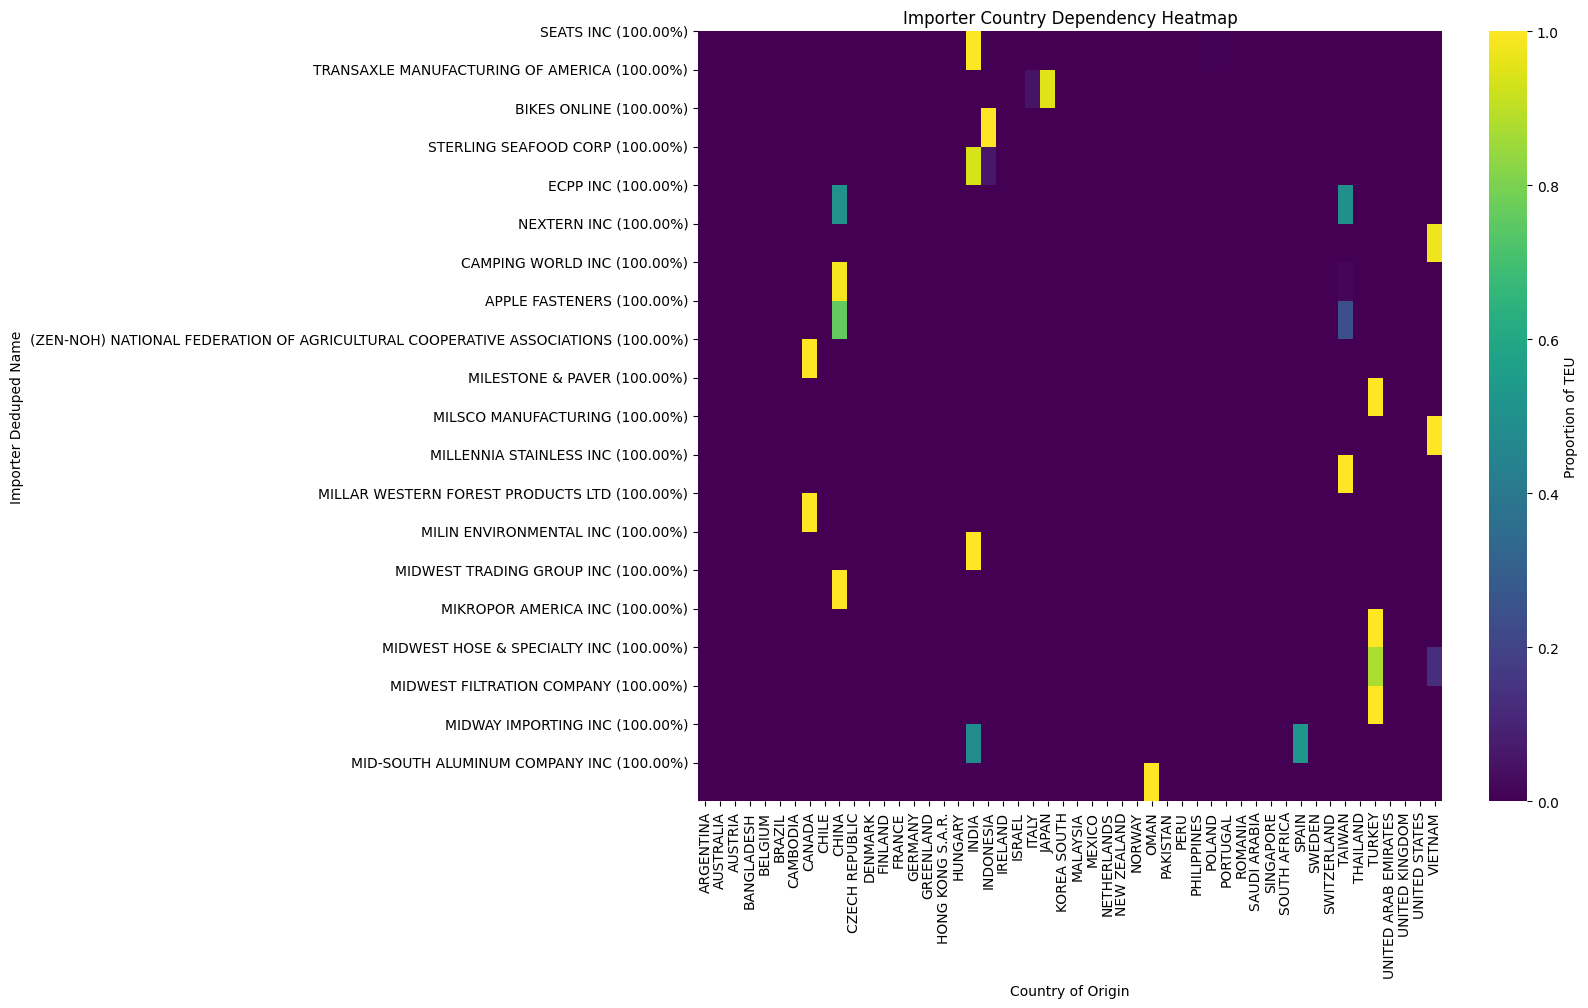

In [34]:
# Reveal top countries of origin per importer
top_countries_per_importer = (
    clean_import_table.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
    .sum()
    .reset_index()
    .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
)
# Identify companies with 50% imports from a single country
companies_50pct_single_country = []
for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
    total_teu = group["calculated_teu_numeric"].sum()
    top_country_teu = group.iloc[0]["calculated_teu_numeric"]
    if top_country_teu / total_teu >= 0.5:
        companies_50pct_single_country.append((importer, group.iloc[0]["country_of_origin"], top_country_teu / total_teu))
print("\nCompanies with >=50% imports from a single country:")
for importer, country, pct in companies_50pct_single_country:
    print(f"{importer}: {country} ({pct:.2%})")

# Identify companies with 70% imports from top 2 countries
companies_70pct_top2_countries = []
for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
    total_teu = group["calculated_teu_numeric"].sum()
    top2_countries_teu = group.iloc[:2]["calculated_teu_numeric"].sum()
    if top2_countries_teu / total_teu >= 0.7:
        companies_70pct_top2_countries.append((importer, top2_countries_teu / total_teu))
print("\nCompanies with >=70% imports from top 2 countries:")
# show the importers and respective countries with corresponding percentages
for importer, pct in companies_70pct_top2_countries:
    print(f"{importer}: ({pct:.2%})")


# Provide high-risk importer list based on the above dependency analysis
high_risk_importers = set()
for importer, country, pct in companies_50pct_single_country:
    high_risk_importers.add(importer)
for importer, pct in companies_70pct_top2_countries:
    high_risk_importers.add(importer)
print("\nHigh-Risk Importers based on Country Dependency Analysis:")
for importer in high_risk_importers:
    print(importer) 

# Visualize country dependency heatmaps
import seaborn as sns

top30_countries = (
    clean_import_table.groupby("country_of_origin")["calculated_teu_numeric"]
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index
)

# Build full heatmap data (proportion of TEU per importer)
heatmap_data = top_countries_per_importer.pivot_table(
    index="importer_deduped_name",
    columns="country_of_origin",
    values="calculated_teu_numeric",
    fill_value=0
)
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

# Compute dependency ratio from heatmap data (top 2 countries share)
dependency_ratio = heatmap_data.apply(lambda row: row.nlargest(2).sum(), axis=1)

# Top n high-risk importers (by dependency ratio), only those >= 70%
high_risk_top20 = (
    dependency_ratio[dependency_ratio >= 0.7]
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Keep only top 20 countries and top 20 high-risk importers (preserve pct order)
heatmap_data_top20 = heatmap_data.loc[
    high_risk_top20,
    heatmap_data.columns.isin(top30_countries)
]

# Plot heatmap (top 20 countries only, top 100 high-risk importers only)
# Plot heatmap (top 20 countries only, top 100 high-risk importers only)
plt.figure(figsize=(12, 10))
ax = sns.heatmap(heatmap_data_top20, cmap="viridis", cbar_kws={"label": "Proportion of TEU"})

# Force y-ticks to show every importer in order, with dependency ratio
labels_with_ratio = [
    f"{name} ({dependency_ratio.loc[name]:.2%})" for name in high_risk_top20
]
ax.set_yticks(range(len(high_risk_top20)))
ax.set_yticklabels(labels_with_ratio, rotation=0)

plt.title("Importer Country Dependency Heatmap")
plt.xlabel("Country of Origin")
plt.ylabel("Importer Deduped Name")
plt.show()

# --- END IGNORE ---

## Diversification profile

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1274834032.py:18: RuntimeWarning: invalid value encountered in scalar divide
  if cumulative_teu / total_teu >= threshold:



Proportion of Importers by Country Dependency (>=80% imports):
1 countries: 57.75%
2 countries: 27.78%
3 countries: 9.80%
4 countries: 3.06%
5 countries: 1.01%
6 or more countries: 0.61%


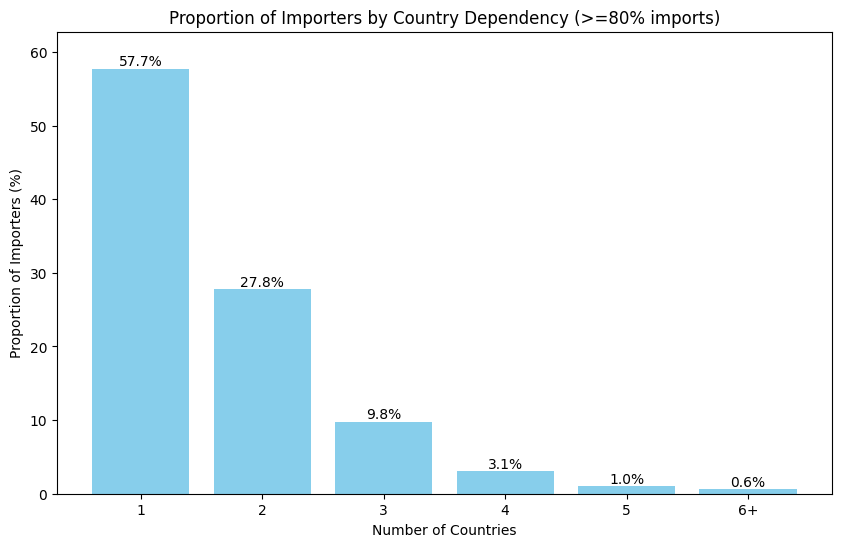

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1274834032.py:90: RuntimeWarning: invalid value encountered in scalar divide
  if cumulative_teu / total_teu >= threshold:


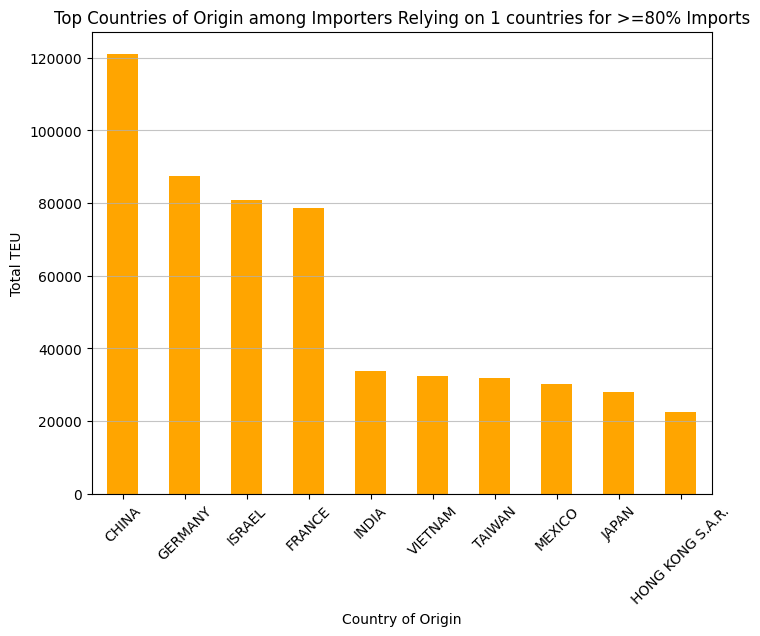

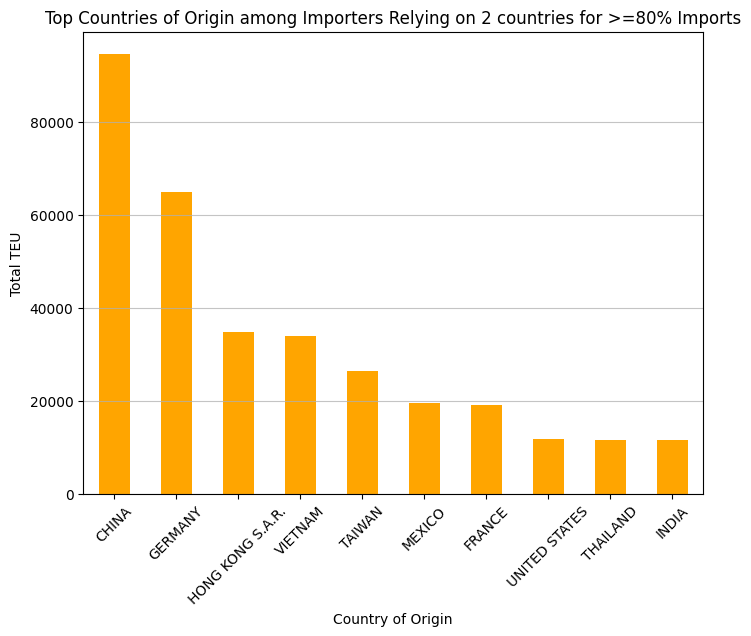

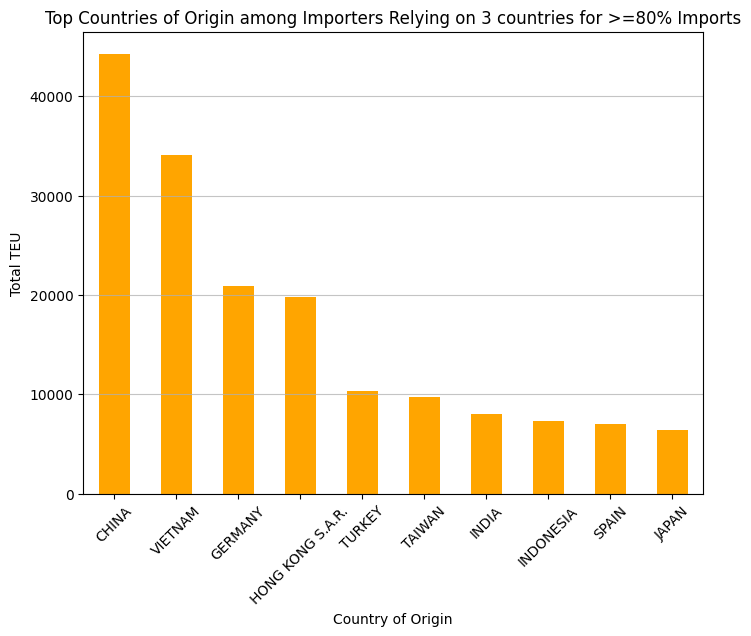

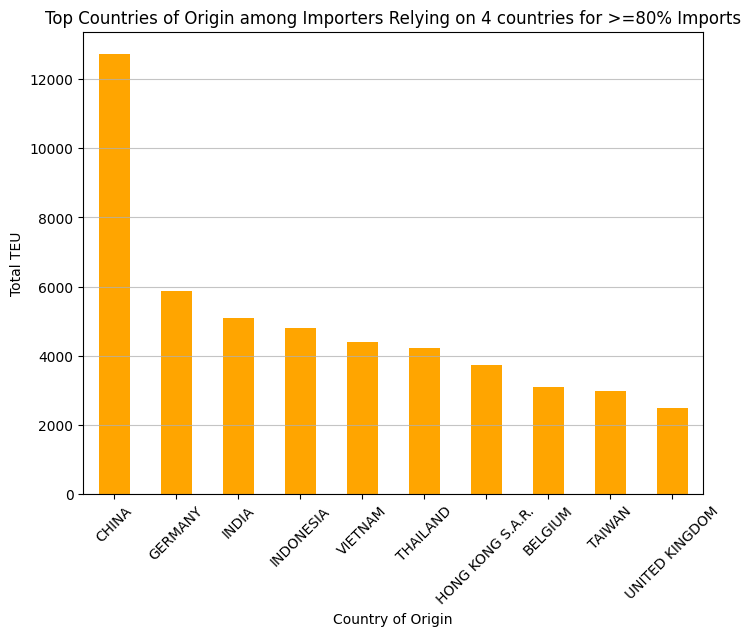

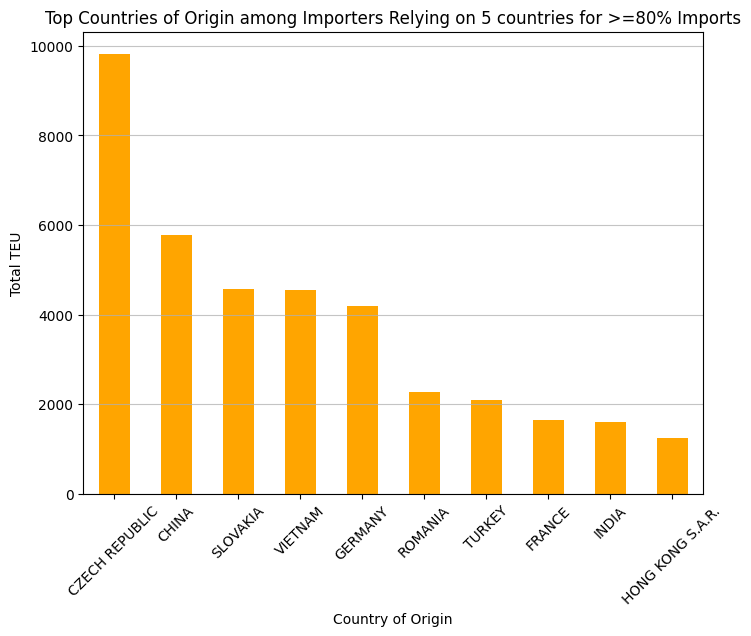

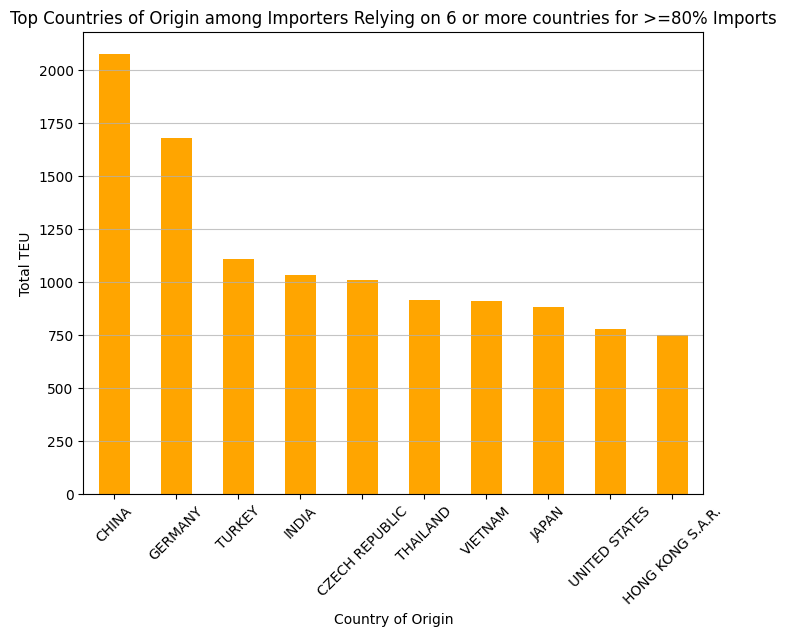

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1274834032.py:132: RuntimeWarning: invalid value encountered in scalar divide
  if cumulative_teu / total_teu >= threshold:


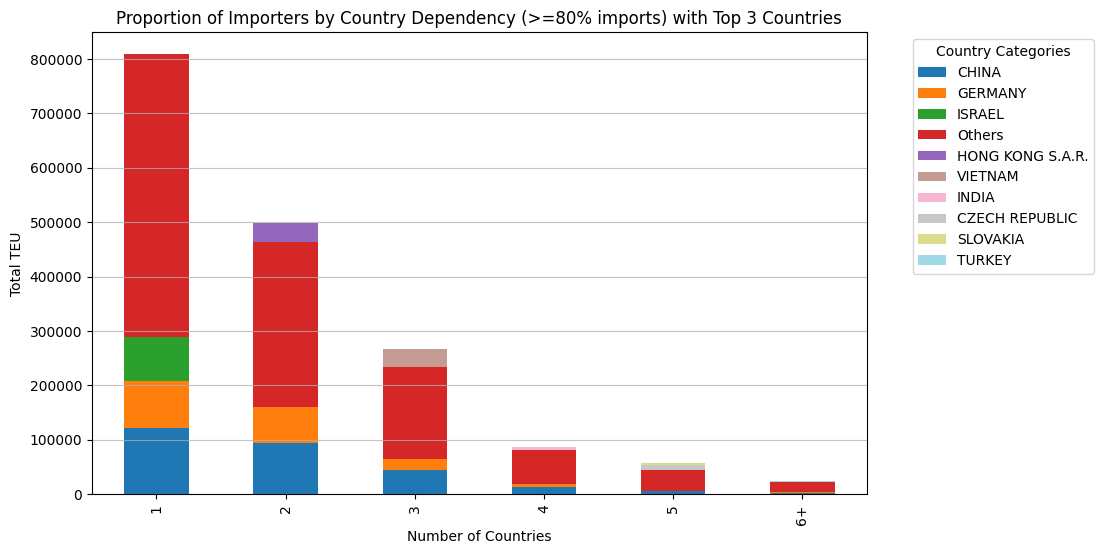

In [35]:
# Get the proportion of all importers that rely on top 1, 2, 3, 4, 5, and 6 or more countries for >=80% of their imports
def proportion_importers_by_country_dependency(df, threshold=0.8):
    top_countries_per_importer = (
        df.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
        .sum()
        .reset_index()
        .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
    )

    dependency_counts = {}
    for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
        total_teu = group["calculated_teu_numeric"].sum()
        cumulative_teu = 0
        country_count = 0
        for _, row in group.iterrows():
            cumulative_teu += row["calculated_teu_numeric"]
            country_count += 1
            if cumulative_teu / total_teu >= threshold:
                break
        dependency_counts[importer] = country_count

    dependency_series = pd.Series(dependency_counts)
    proportion_distribution = dependency_series.value_counts(normalize=True).sort_index()

    # Aggregate counts for 6 or more countries
    if len(proportion_distribution) > 6:
        others_sum = proportion_distribution[proportion_distribution.index >= 6].sum()
        proportion_distribution = proportion_distribution[proportion_distribution.index < 6]
        proportion_distribution.loc[6] = others_sum

    return proportion_distribution.sort_index()

proportion_distribution = proportion_importers_by_country_dependency(clean_import_table, threshold=0.8)
print("\nProportion of Importers by Country Dependency (>=80% imports):")
for country_count, proportion in proportion_distribution.items():
    label = f"{country_count} countries" if country_count < 6 else "6 or more countries"
    print(f"{label}: {proportion:.2%}")

# Visualize bar chart with percent labels
# --- IGNORE ---
plt.figure(figsize=(10, 6))
bars = plt.bar(
    proportion_distribution.index.map(lambda x: f"{x}" if x < 6 else "6+"),
    proportion_distribution.values * 100,
    color="skyblue"
)
plt.title("Proportion of Importers by Country Dependency (>=80% imports)")
plt.xlabel("Number of Countries")
plt.ylabel("Proportion of Importers (%)")
plt.ylim(0, max(proportion_distribution.values) * 100 + 5)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()   
# --- END IGNORE ---

# Each importer has top 3 countries of origin by TEU volume
top_countries_per_importer = (
    clean_import_table.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
    .sum()
    .reset_index()
    .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
)
top_3_countries_per_importer = top_countries_per_importer.groupby("importer_deduped_name").head(3)
# Aggregate across all importers to plot the top countries among those importers relying >=80% of their imports on 1, 2, 3, 4, 5, and 6 or more countries
# --- IGNORE ---
def plot_top_countries_among_dependency_groups(df, threshold=0.8):
    top_countries_per_importer = (
        df.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
        .sum()
        .reset_index()
        .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
    )

    dependency_groups = {i: [] for i in range(1, 7)}  # 1 to 6 or more countries

    for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
        total_teu = group["calculated_teu_numeric"].sum()
        cumulative_teu = 0
        country_count = 0
        for _, row in group.iterrows():
            cumulative_teu += row["calculated_teu_numeric"]
            country_count += 1
            if cumulative_teu / total_teu >= threshold:
                break
        key = country_count if country_count < 6 else 6
        dependency_groups[key].append(importer)

    for country_count, importers in dependency_groups.items():
        subset = top_countries_per_importer[top_countries_per_importer["importer_deduped_name"].isin(importers)]
        country_distribution = subset.groupby("country_of_origin")["calculated_teu_numeric"].sum().sort_values(ascending=False)

        plt.figure(figsize=(8, 6))
        country_distribution.head(10).plot(kind="bar", color="orange")
        label = f"{country_count} countries" if country_count < 6 else "6 or more countries"
        plt.title(f"Top Countries of Origin among Importers Relying on {label} for >=80% Imports")
        plt.xlabel("Country of Origin")
        plt.ylabel("Total TEU")
        plt.xticks(rotation=45)
        plt.grid(axis="y", alpha=0.75)
        plt.show()
# --- END IGNORE ---
plot_top_countries_among_dependency_groups(clean_import_table, threshold=0.8)

# Plot again the proportion of importers by country dependency (>=80% imports): 1, 2, 3, 4, 5, and 6 or more countries
# But now each bar stacks the top 3 countries of origin by TEU volume, and "others" category
# Name each top 3 countries for every bar   
# --- IGNORE ---
def plot_stacked_top_countries_dependency(df, threshold=0.8):
    top_countries_per_importer = (
        df.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
        .sum()
        .reset_index()
        .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
    )

    dependency_groups = {i: [] for i in range(1, 7)}  # 1 to 6 or more countries

    for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
        total_teu = group["calculated_teu_numeric"].sum()
        cumulative_teu = 0
        country_count = 0
        for _, row in group.iterrows():
            cumulative_teu += row["calculated_teu_numeric"]
            country_count += 1
            if cumulative_teu / total_teu >= threshold:
                break
        key = country_count if country_count < 6 else 6
        dependency_groups[key].append(importer)

    stacked_data = {}
    for country_count, importers in dependency_groups.items():
        subset = top_countries_per_importer[top_countries_per_importer["importer_deduped_name"].isin(importers)]
        country_distribution = subset.groupby("country_of_origin")["calculated_teu_numeric"].sum().sort_values(ascending=False)

        top3 = country_distribution.head(3)
        others = country_distribution.sum() - top3.sum()

        row = {country: value for country, value in top3.items()}
        row["Others"] = others
        stacked_data[country_count] = row

    stacked_df = pd.DataFrame.from_dict(stacked_data, orient="index").fillna(0)
    stacked_df.index = stacked_df.index.map(lambda x: f"{x}" if x < 6 else "6+")

    stacked_df.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab20")
    plt.title("Proportion of Importers by Country Dependency (>=80% imports) with Top 3 Countries")
    plt.xlabel("Number of Countries")
    plt.ylabel("Total TEU")
    plt.legend(title="Country Categories", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(axis="y", alpha=0.75)
    plt.show()
# --- END IGNORE ---
plot_stacked_top_countries_dependency(clean_import_table, threshold=0.8)
# --- IGNORE ---


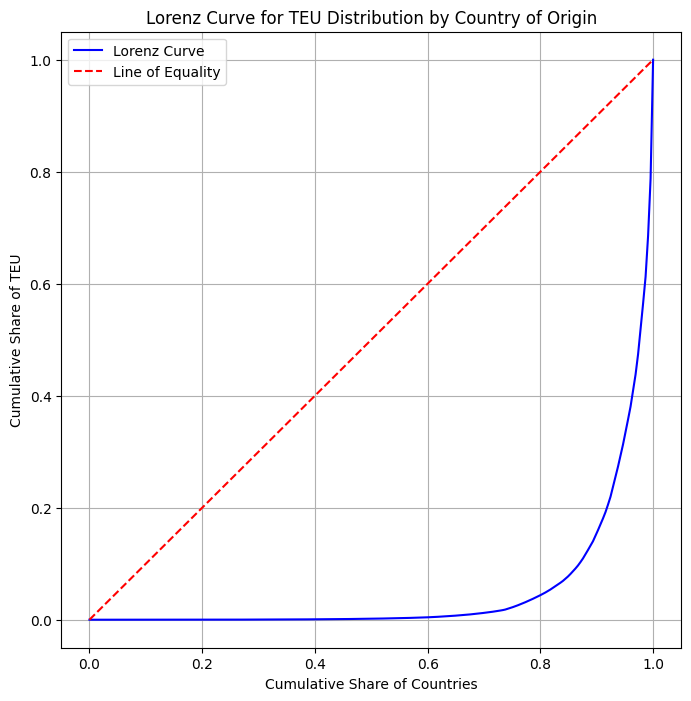


Gini Coefficient for TEU Distribution by Country of Origin: 0.8995


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/3020749903.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini_coefficient = 1 - 2 * np.trapz(cumulative_teu, x)


In [36]:
# Plot the Lorenz curve printed on which is the Gini coefficient for TEU distribution per country of origin
def plot_lorenz_curve(teu_values):
    sorted_teu = np.sort(teu_values)
    cumulative_teu = np.cumsum(sorted_teu)
    cumulative_teu = np.insert(cumulative_teu, 0, 0)
    cumulative_teu /= cumulative_teu[-1]

    n = len(teu_values)
    x = np.linspace(0, 1, n + 1)

    plt.figure(figsize=(8, 8))
    plt.plot(x, cumulative_teu, label="Lorenz Curve", color="blue")
    plt.plot([0, 1], [0, 1], label="Line of Equality", color="red", linestyle="--")
    plt.title("Lorenz Curve for TEU Distribution by Country of Origin")
    plt.xlabel("Cumulative Share of Countries")
    plt.ylabel("Cumulative Share of TEU")
    plt.legend()
    plt.grid()
    plt.show()

    # Calculate Gini coefficient
    gini_coefficient = 1 - 2 * np.trapz(cumulative_teu, x)
    return gini_coefficient
country_teu_values = clean_import_table.groupby("country_of_origin")["calculated_teu_numeric"].sum().dropna()
gini_coeff_country = plot_lorenz_curve(country_teu_values)
print(f"\nGini Coefficient for TEU Distribution by Country of Origin: {gini_coeff_country:.4f}") 
# --- END IGNORE ---


## Company Segmentation
* High-volume/Low-diversification (>=200 TEU, >=80%TEU to 1-2 countries)
* High-volume/High-diversiication (>=200 TEU, >=80%TEU to 3 or more countries )
* Low-volume/High-diversification (<200 TEU, >=80%TEU to 3 or more countries)
* Low-volume/Low-diversification (<200 TEU, >=80%TEU to 1-2 countries)

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/3993753027.py:29: RuntimeWarning: invalid value encountered in scalar divide
  if cumulative_teu / total_teu >= diversification_threshold:


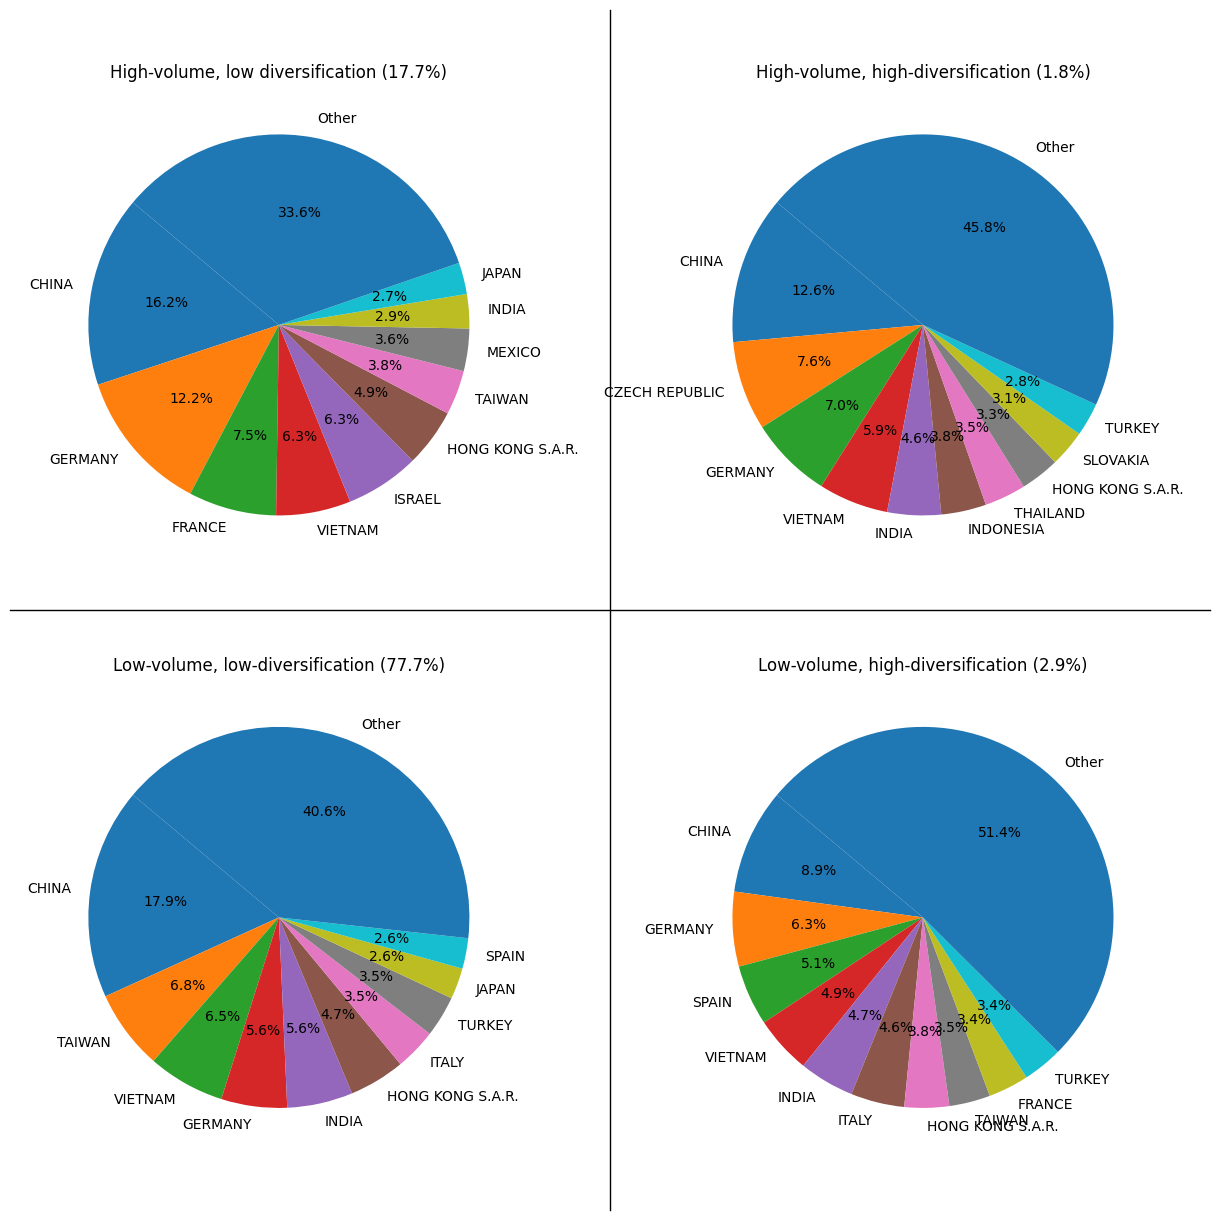

In [37]:
# Segment company importers based on:
# Segment 1: High-volume/Low-diversification (>=200 TEU, >=80%TEU to 1-2 countries)
# Segment 2: High-volume/High-diversiication (>=200 TEU, >=80%TEU to 3 or more countries )
# Segment 3: Low-volume/Low-diversification (<200 TEU, >=80%TEU to 1-2 countries)
# Segment 4: Low-volume/High-diversification (<200 TEU, >=80%TEU to 3 or more countries)
# For each segment plot a pie chart of country of origin distribution
# Create a four-panel pie chart putting Segment 1 in the top-left quadrant, Segment 2 in the top-right quadrant,
# Segment 3 in the bottom-left quadrant, and Segment 4 in the bottom-right quadrant

threshold_diversification = 3 # number of countries below which is considered low diversification
# --- IGNORE ---
def segment_importers(df, volume_threshold=200, diversification_threshold=0.8):
    top_countries_per_importer = (
        df.groupby(["importer_deduped_name", "country_of_origin"])["calculated_teu_numeric"]
        .sum()
        .reset_index()
        .sort_values(["importer_deduped_name", "calculated_teu_numeric"], ascending=[True, False])
    )

    segments = {1: [], 2: [], 3: [], 4: []}

    for importer, group in top_countries_per_importer.groupby("importer_deduped_name"):
        total_teu = group["calculated_teu_numeric"].sum()
        cumulative_teu = 0
        country_count = 0
        for _, row in group.iterrows():
            cumulative_teu += row["calculated_teu_numeric"]
            country_count += 1
            if cumulative_teu / total_teu >= diversification_threshold:
                break

        if total_teu >= volume_threshold:
            if country_count <= threshold_diversification:
                segments[1].append(importer)
            else:
                segments[2].append(importer)
        else:
            if country_count <= threshold_diversification:
                segments[3].append(importer)
            else:
                segments[4].append(importer)

    return segments
segments = segment_importers(clean_import_table, volume_threshold=200, diversification_threshold=0.8)

total_importers = clean_import_table["importer_deduped_name"].nunique()
segment_pct = {
    i: (len(segments[i]) / total_importers * 100) if total_importers else 0
    for i in range(1, 5)
}

segment_titles = {
    1: f"High-volume, low diversification ({segment_pct[1]:.1f}%)",
    2: f"High-volume, high-diversification ({segment_pct[2]:.1f}%)",
    3: f"Low-volume, low-diversification ({segment_pct[3]:.1f}%)",
    4: f"Low-volume, high-diversification ({segment_pct[4]:.1f}%)",
}

# Plot four-panel pie chart
fig = plt.figure(figsize=(12, 12))
for i in range(1, 5):
    subset = clean_import_table[
        clean_import_table["importer_deduped_name"].isin(segments[i])
    ]
    country_distribution = subset.groupby("country_of_origin")["calculated_teu_numeric"].sum().sort_values(ascending=False)

    plt.subplot(2, 2, i)
    top_countries = country_distribution.head(10)
    others = country_distribution.sum() - top_countries.sum()
    pie_data = pd.concat([top_countries, pd.Series({"Other": others})])
    pie_data.plot(kind="pie", autopct="%1.1f%%", startangle=140)
    plt.title(segment_titles.get(i, f"Segment {i}"))
    plt.ylabel("")
# Add quadrant bisectors
from matplotlib.lines import Line2D
fig.add_artist(Line2D([0.5, 0.5], [0.0, 1.0], transform=fig.transFigure, color="black", linewidth=1))
fig.add_artist(Line2D([0.0, 1.0], [0.5, 0.5], transform=fig.transFigure, color="black", linewidth=1))
plt.tight_layout()
plt.show()
# --- END IGNORE ---

## Segment Summary

| Segment   | Interpretation         | Investment Lens               |
| --------- | ---------------------- | ----------------------------- |
| Segment 1 | Large but concentrated | **Supply-chain risk**         |
| Segment 2 | Large and diversified  | **Resilient / best-in-class** |
| Segment 3 | Small and concentrated | **Fragile long tail**         |
| Segment 4 | Small but diversified  | **Promising growth segment**  |


## Ports and Logistics Analysis
**Purpose:** Understand logistics bottlenecks and routing strategies
* TEU flow by port
* Port concentration by company
* Port-country interaction (e.g., China --> LA/LB dominance)
* Identify:
    * Port reliance risk
    * Logistics diversification leaders

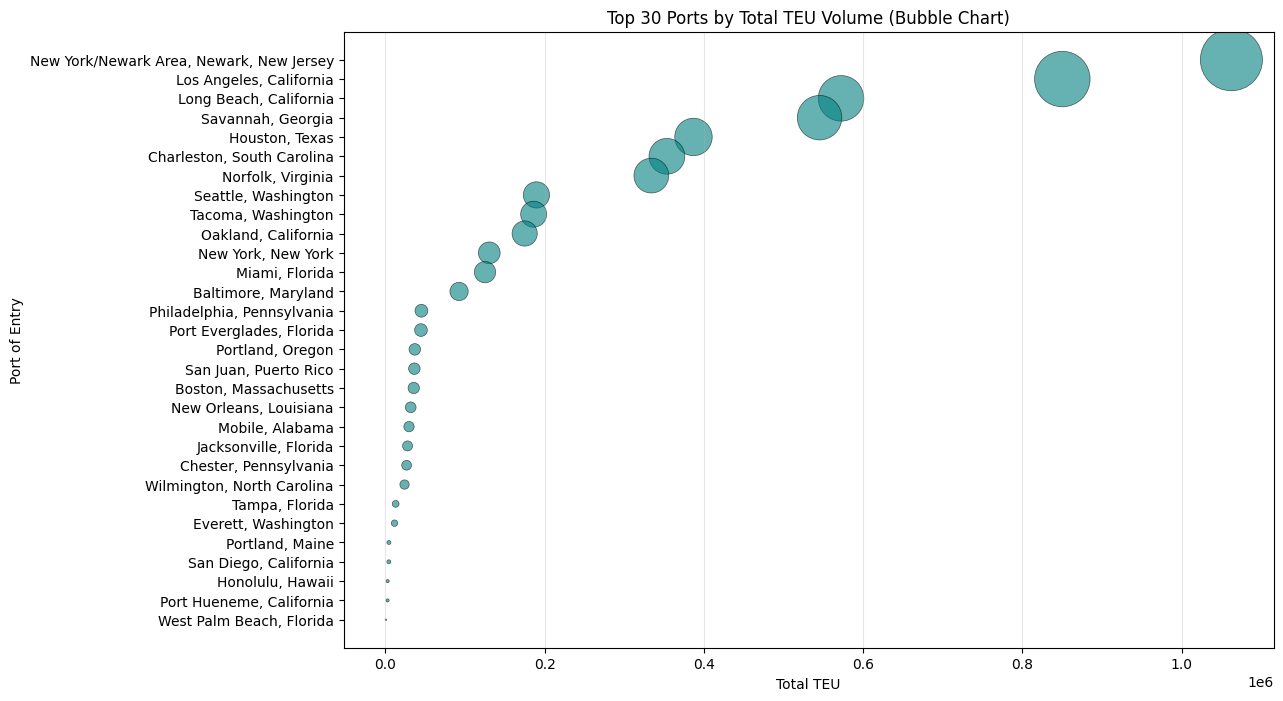

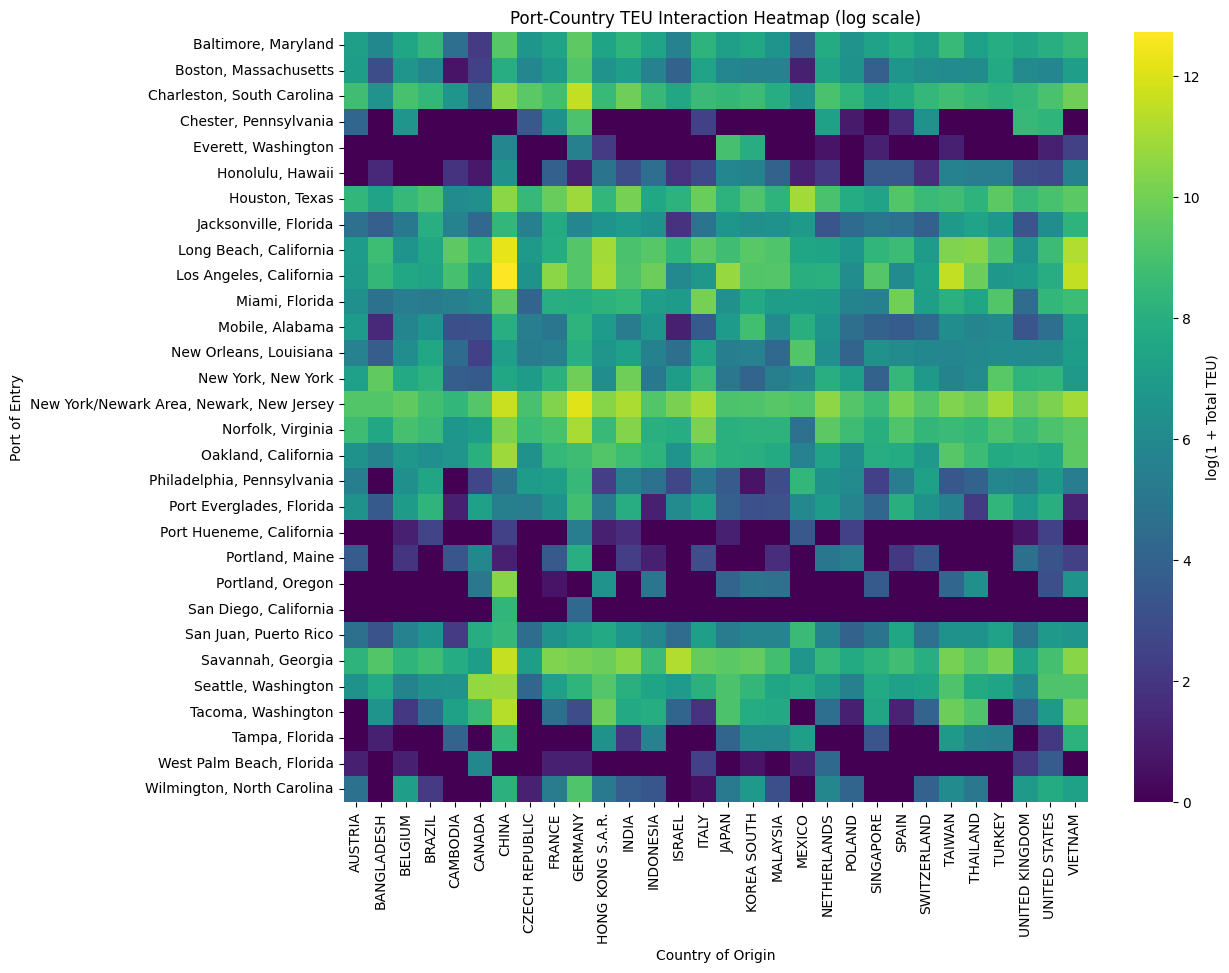

In [38]:
# Visualize TEU flow by port
# Create a bar chart showing total TEU volume per port of entry
# Use port_name from ports_df for labeling
import string


port_teu_distribution = (
    clean_import_table.groupby("port_name")["calculated_teu_numeric"]
    .sum()
    .sort_values(ascending=False)
)
# --- IGNORE ---
n = 30
top_ports = port_teu_distribution.head(n).reset_index()
top_ports.columns = ["port_name", "total_teu"]
top_ports["rank"] = range(len(top_ports), 0, -1)

plt.figure(figsize=(12, 8))
sizes = (top_ports["total_teu"] / top_ports["total_teu"].max()) * 2000
plt.scatter(
    top_ports["total_teu"],
    top_ports["rank"],
    s=sizes,
    alpha=0.6,
    color="teal",
    edgecolors="black",
    linewidths=0.5
)
plt.yticks(top_ports["rank"], top_ports["port_name"])
plt.title(f"Top {n} Ports by Total TEU Volume (Bubble Chart)")
plt.xlabel("Total TEU")
plt.ylabel("Port of Entry")
plt.grid(axis="x", alpha=0.3)
plt.show()
# --- END IGNORE ---

# Visualize port-country interactions
# Create a heatmap showing TEU volume for top 30 ports and top 30 countries of origin
#n = 30
topn_ports = port_teu_distribution.head(n).index
topn_countries = (
    clean_import_table.groupby("country_of_origin")["calculated_teu_numeric"]
    .sum()
    .sort_values(ascending=False)
    .head(n)
    .index
)
heatmap_data_port_country = clean_import_table[
    clean_import_table["port_name"].isin(topn_ports) &
    clean_import_table["country_of_origin"].isin(topn_countries)
].pivot_table(
    index="port_name",
    columns="country_of_origin",
    values="calculated_teu_numeric",
    aggfunc="sum",
    fill_value=0
)
# --- IGNORE ---
plt.figure(figsize=(12, 10))
log_heatmap_data = np.log1p(heatmap_data_port_country)
ax = sns.heatmap(log_heatmap_data, cmap="viridis", cbar_kws={"label": "log(1 + Total TEU)"})
plt.title("Port-Country TEU Interaction Heatmap (log scale)")
plt.xlabel("Country of Origin")
plt.ylabel("Port of Entry")
plt.show()
# --- END IGNORE ---

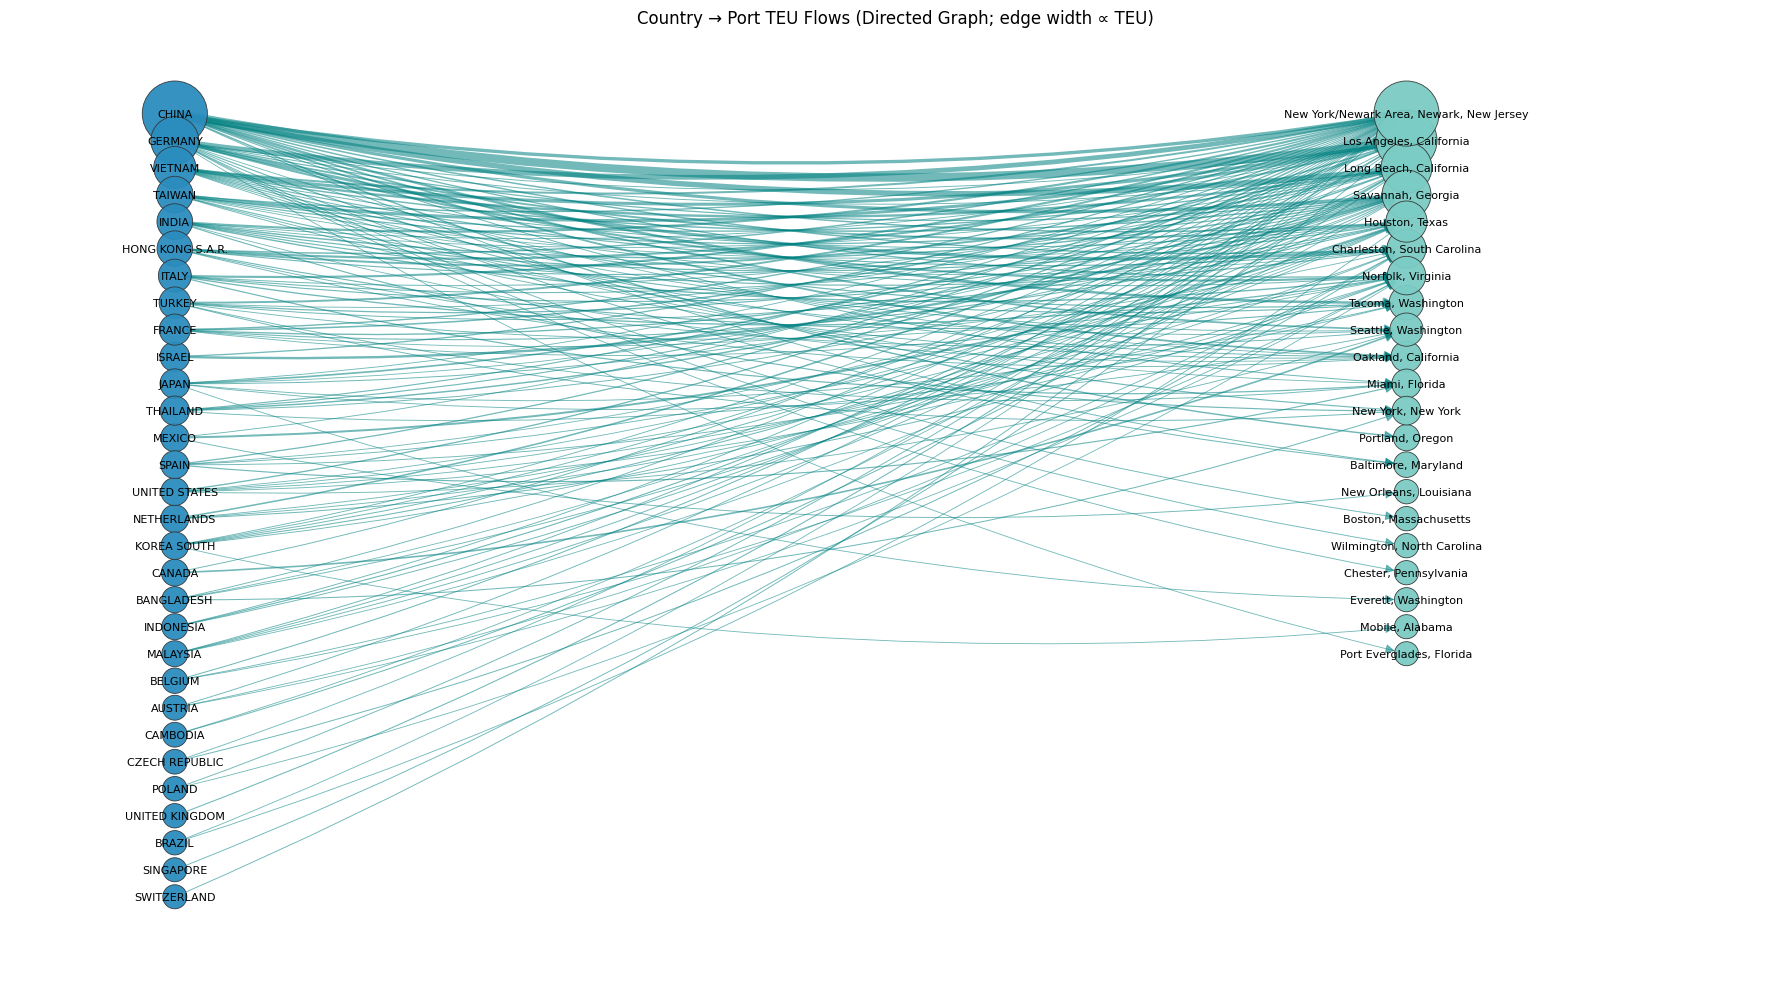

In [39]:

# Add geographic context
# Visualize port-country interactions as a directed graph (countries -> ports)
# Edge thickness proportional to TEU
# --- IGNORE ---
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Build flows for top N ports/countries
topn_ports = port_teu_distribution.head(n).index
topn_countries = (
    clean_import_table.groupby("country_of_origin")["calculated_teu_numeric"]
    .sum()
    .sort_values(ascending=False)
    .head(n)
    .index
)

flows = (
    clean_import_table[
        clean_import_table["port_name"].isin(topn_ports)
        & clean_import_table["country_of_origin"].isin(topn_countries)
    ]
    .groupby(["country_of_origin", "port_name"])["calculated_teu_numeric"]
    .sum()
    .reset_index()
    .rename(columns={"calculated_teu_numeric": "teu"})
)

# Optional: keep only the strongest edges so the graph stays readable
top_m_edges = 150
if len(flows) > top_m_edges:
    flows = flows.sort_values("teu", ascending=False).head(top_m_edges)

# Build directed bipartite graph (countries -> ports)
G = nx.DiGraph()

countries = flows["country_of_origin"].unique().tolist()
ports = flows["port_name"].unique().tolist()

G.add_nodes_from(countries, node_type="country")
G.add_nodes_from(ports, node_type="port")

for _, r in flows.iterrows():
    G.add_edge(r["country_of_origin"], r["port_name"], teu=float(r["teu"]))

# Node sizes (scaled by total TEU)
country_out = flows.groupby("country_of_origin")["teu"].sum()
port_in = flows.groupby("port_name")["teu"].sum()

def _scale(series, min_size=300, max_size=2200):
    if series.empty:
        return {}
    vmin, vmax = float(series.min()), float(series.max())
    if vmax == vmin:
        return {k: (min_size + max_size) / 2 for k in series.index}
    return {
        k: min_size + (float(v) - vmin) / (vmax - vmin) * (max_size - min_size)
        for k, v in series.items()
    }

country_sizes = _scale(country_out)
port_sizes = _scale(port_in)

node_sizes = [
    country_sizes.get(node, 600) if G.nodes[node].get("node_type") == "country" else port_sizes.get(node, 600)
    for node in G.nodes()
]

# Bipartite-ish layout: countries on left, ports on right
countries_sorted = country_out.sort_values(ascending=False).index.tolist()
ports_sorted = port_in.sort_values(ascending=False).index.tolist()

pos = {}
for i, c in enumerate(countries_sorted):
    pos[c] = (0.0, -i)
for i, p in enumerate(ports_sorted):
    pos[p] = (1.0, -i)

# Edge widths proportional to TEU
teu_vals = [G.edges[e]["teu"] for e in G.edges]
max_teu = max(teu_vals) if teu_vals else 1.0
min_w, max_w = 0.5, 6.0
edge_widths = [min_w + (G.edges[e]["teu"] / max_teu) * (max_w - min_w) for e in G.edges]

# Draw
plt.figure(figsize=(18, 10))
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=["#2b8cbe" if G.nodes[n].get("node_type") == "country" else "#7bccc4" for n in G.nodes()],
    edgecolors="#333333",
    linewidths=0.6,
    alpha=0.95,
)
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    edge_color="teal",
    alpha=0.55,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=14,
    connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Country → Port TEU Flows (Directed Graph; edge width ∝ TEU)")
plt.axis("off")
plt.tight_layout()
plt.show()
# --- END IGNORE ---


## Early-Warning Classifier for Segment-1 Risk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Segment 1 prevalence (full-year): 14.959%  (1174 / 7848)
Split sizes: train=4805, val=1030, test=1030
Pos rates:   train=16.961%, val=16.893%, test=16.990%
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[20]	train's auc: 0.980756	train's average_precision: 0.926302	val's auc: 0.961116	val's average_precision: 0.887274

=== Test Metrics ===
ROC AUC : 0.9461
PR  AUC : 0.8667

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9560    0.9404    0.9481       855
           1     0.7302    0.7886    0.7582       175

    accuracy                         0.9146      1030
   macro avg     0.8431    0.8645    0.8532      1030
weighted avg     0.9176    0.9146    0.9159      1030


=== Feature Importance (gain) ===
                feature  importance_gain  importance_split
0 

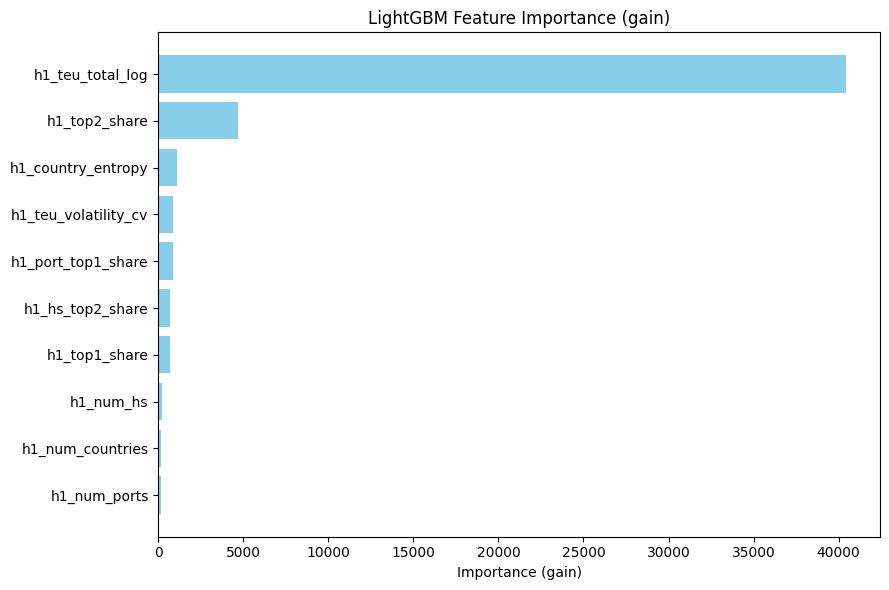


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

=== Linear mimic (raw-unit) coefficients ===
Intercept: -2.794079667401865
h1_top2_share           0.382864
h1_teu_total_log        0.198448
h1_teu_volatility_cv    0.117466
h1_top1_share           0.106122
h1_country_entropy     -0.024064
h1_num_countries        0.000000
h1_hs_top2_share        0.000000
h1_port_top1_share      0.000000
h1_num_hs               0.000000
h1_num_ports            0.000000
dtype: float64

=== Suggested linear weights (sum to 1) ===
{'h1_top2_share': 0.4618579251021156, 'h1_teu_total_log': 0.2393927500171929, 'h1_teu_volatility_cv': 0.14170226658274, 'h1_top1_share': 0.12801774777625807, 'h1_country_entropy': 0.029029310520487236, 'h1_num_countries': 0.0, 'h1_hs_top2_share': 0.0, 'h1_port_top1_share': 0.0, 'h1_num_hs': 0.0, 'h1_num_ports': 0.0}


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:395: RuntimeWarning: divide by zero encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:395: RuntimeWarning: overflow encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:395: RuntimeWarning: invalid value encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:397: RuntimeWarning: divide by zero encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:397: RuntimeWarning: overflow encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/204331727.py:397: RuntimeWarning: invalid value encountered in matmul
  loss = (r @ r) / n + alpha *

In [40]:
# ------------------------------------------------------------
# LightGBM Early-warning classifier for Segment 1 risk importers
# Input: partial-year (<= June) sourcing + volume signals
# Output: probability of being Segment 1 by year-end
#
# Segment 1 definition (YEAR-END, full-year):
#   - total TEU >= 200
#   - top2 country share >= 0.80  (>=80% TEU to 1–2 countries)
#
# This cell:
#   1) builds H1 (<= June) importer-level features incl. top1/top2 shares + entropy
#   2) computes year-end Segment 1 labels consistently from the same table
#   3) uses train/val/test split (test is never used for early stopping)
#   4) reports AUC, PR-AUC, Top-K precision
# ------------------------------------------------------------

!pip -q install lightgbm scikit-learn

import ast
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

if "df_base" not in globals():
    if "df" in globals():
        _df_base = df
    elif "clean_import_table" in globals():
        _df_base = clean_import_table
    else:
        raise ValueError("No base DataFrame found (df or clean_import_table)")
df_base = _df_base.copy()

# -----------------------------
# Helpers
# -----------------------------
def _as_list(x):
    """Parse hs_codes into a list robustly."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x if pd.notna(v) and str(v).strip()]
    s = str(x).strip()
    if not s:
        return []
    # Try literal list (e.g., "['0101', '0202']" or "[]")
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(z).strip() for z in v if pd.notna(z) and str(z).strip()]
    except Exception:
        pass
    # Fallback split on common delimiters
    delim = "|" if "|" in s else (";" if ";" in s else ("," if "," in s else None))
    if delim:
        return [p.strip() for p in s.split(delim) if p.strip()]
    return [s]

def _topk_share(grouped: pd.DataFrame, importer_col: str, share_col: str, k: int, out_col: str) -> pd.DataFrame:
    """Given (importer, item, share) rows, compute sum of top-k shares per importer."""
    g = grouped.sort_values([importer_col, share_col], ascending=[True, False])
    topk = (
        g.groupby(importer_col, as_index=False)
         .head(k)
         .groupby(importer_col, as_index=False)[share_col]
         .sum()
         .rename(columns={share_col: out_col})
    )
    return topk

# -----------------------------
# Feature builder (H1 / full-year)
# -----------------------------
def importer_risk_features(
    data: pd.DataFrame,
    cutoff_month: int,
    importer_col: str = "importer_deduped_name",
    country_col: str = "country_of_origin",
    port_col: str = "port_name",          # uses port_name (already merged from ports_df)
    hs_col: str = "hs_codes",
    teu_col: str = "calculated_teu_numeric",
    month_col: str = "file_month",
    prefix: str = "h1_",
) -> pd.DataFrame:
    d = data.loc[data[month_col] <= cutoff_month, [importer_col, country_col, port_col, hs_col, teu_col, month_col]].copy()

    # -----------------------------
    # Base totals (RAW + LOG-SCALED)
    # -----------------------------
    totals = (
        d.groupby(importer_col, as_index=False)[teu_col]
         .sum()
         .rename(columns={teu_col: f"{prefix}teu_total"})
    )
    # log1p to handle zeros; clip lower bound for safety
    totals[f"{prefix}teu_total_log"] = np.log1p(totals[f"{prefix}teu_total"].clip(lower=0))

    # -----------------------------
    # Country concentration
    # -----------------------------
    ic = (
        d.groupby([importer_col, country_col], as_index=False)[teu_col]
         .sum()
         .rename(columns={teu_col: "teu_ic"})
    )
    ic = ic.merge(totals[[importer_col, f"{prefix}teu_total"]], on=importer_col, how="left")
    ic["share"] = ic["teu_ic"] / (ic[f"{prefix}teu_total"] + 1e-9)

    num_countries = (
        ic.groupby(importer_col, as_index=False)[country_col]
          .nunique()
          .rename(columns={country_col: f"{prefix}num_countries"})
    )
    top1_country = _topk_share(ic[[importer_col, "share"]].copy(), importer_col, "share", 1, f"{prefix}top1_share")
    top2_country = _topk_share(ic[[importer_col, "share"]].copy(), importer_col, "share", 2, f"{prefix}top2_share")

    entropy = (
        ic.groupby(importer_col)["share"]
          .apply(lambda s: -(s[s > 0] * np.log(s[s > 0])).sum())
          .reset_index()
          .rename(columns={"share": f"{prefix}country_entropy"})
    )

    # -----------------------------
    # HS concentration (product risk): top-2 HS share
    # -----------------------------
    hs_d = d[[importer_col, hs_col, teu_col]].copy()
    hs_d["hs_list"] = hs_d[hs_col].apply(_as_list)
    hs_ex = hs_d.explode("hs_list")
    hs_ex = hs_ex.loc[hs_ex["hs_list"].notna() & (hs_ex["hs_list"].astype(str).str.strip() != "")]
    ihs = (
        hs_ex.groupby([importer_col, "hs_list"], as_index=False)[teu_col]
             .sum()
             .rename(columns={teu_col: "teu_ihs"})
    )
    ihs = ihs.merge(totals[[importer_col, f"{prefix}teu_total"]], on=importer_col, how="left")
    ihs["hs_share"] = ihs["teu_ihs"] / (ihs[f"{prefix}teu_total"] + 1e-9)

    hs_top2 = _topk_share(
        ihs[[importer_col, "hs_share"]].rename(columns={"hs_share": "share"}),
        importer_col,
        "share",
        2,
        f"{prefix}hs_top2_share",
    )
    num_hs = (
        ihs.groupby(importer_col, as_index=False)["hs_list"]
           .nunique()
           .rename(columns={"hs_list": f"{prefix}num_hs"})
    )

    # -----------------------------
    # Port concentration (logistics risk): top-1 port share
    # -----------------------------
    ip = (
        d.groupby([importer_col, port_col], as_index=False)[teu_col]
         .sum()
         .rename(columns={teu_col: "teu_ip"})
    )
    ip = ip.merge(totals[[importer_col, f"{prefix}teu_total"]], on=importer_col, how="left")
    ip["port_share"] = ip["teu_ip"] / (ip[f"{prefix}teu_total"] + 1e-9)

    port_top1 = _topk_share(
        ip[[importer_col, "port_share"]].rename(columns={"port_share": "share"}),
        importer_col,
        "share",
        1,
        f"{prefix}port_top1_share",
    )
    num_ports = (
        ip.groupby(importer_col, as_index=False)[port_col]
          .nunique()
          .rename(columns={port_col: f"{prefix}num_ports"})
    )

    # -----------------------------
    # Month-to-month TEU volatility (stability): CV across months in window
    # -----------------------------
    m = (
        d.groupby([importer_col, month_col], as_index=False)[teu_col]
         .sum()
         .rename(columns={teu_col: "teu_month"})
    )
    vol = (
        m.groupby(importer_col)["teu_month"]
         .agg(monthly_mean="mean", monthly_std="std", months_obs="count")
         .reset_index()
    )
    vol[f"{prefix}teu_volatility_cv"] = vol["monthly_std"] / (vol["monthly_mean"] + 1e-9)
    vol = vol[[importer_col, f"{prefix}teu_volatility_cv"]]

    # -----------------------------
    # Assemble feature table
    # -----------------------------
    feats = (
        totals
        .merge(num_countries, on=importer_col, how="left")
        .merge(top1_country, on=importer_col, how="left")
        .merge(top2_country, on=importer_col, how="left")
        .merge(entropy, on=importer_col, how="left")
        .merge(hs_top2, on=importer_col, how="left")
        .merge(num_hs, on=importer_col, how="left")
        .merge(port_top1, on=importer_col, how="left")
        .merge(num_ports, on=importer_col, how="left")
        .merge(vol, on=importer_col, how="left")
    )

    return feats

# -----------------------------
# Build YEAR-END labels (unchanged definition; uses RAW y_teu_total)
# -----------------------------
year_feats = importer_risk_features(df_base, cutoff_month=12, prefix="y_")
year_feats["is_segment1"] = ((year_feats["y_teu_total"] >= 200) & (year_feats["y_top2_share"] >= 0.80)).astype(int)

seg1_rate = year_feats["is_segment1"].mean()
print(f"Segment 1 prevalence (full-year): {seg1_rate:.3%}  ({year_feats['is_segment1'].sum()} / {len(year_feats)})")

# -----------------------------
# Build H1 (<= June) features (expanded)
# -----------------------------
h1_feats = importer_risk_features(df_base, cutoff_month=6, prefix="h1_")

data_model = h1_feats.merge(
    year_feats[["importer_deduped_name", "is_segment1"]],
    on="importer_deduped_name",
    how="inner",
)

# Expanded feature set (TEU TOTAL is now LOG-SCALED)
feature_cols = [
    "h1_teu_total_log",       # <-- changed (log1p scaled)
    "h1_num_countries",
    "h1_top1_share",
    "h1_top2_share",
    "h1_country_entropy",
    "h1_hs_top2_share",       # product risk (HS concentration)
    "h1_port_top1_share",     # logistics risk (port concentration ratio)
    "h1_teu_volatility_cv",   # stability risk (volatility)
    # optional breadth controls:
    "h1_num_hs",
    "h1_num_ports",
]

X = data_model[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = data_model["is_segment1"].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=1234, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=1234, stratify=y_temp
)

print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print(f"Pos rates:   train={y_train.mean():.3%}, val={y_val.mean():.3%}, test={y_test.mean():.3%}")

# -----------------------------
# Train LightGBM
# -----------------------------
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": ["auc", "average_precision"],
    "learning_rate": 0.05,
    "num_leaves": 31,
    "min_data_in_leaf": 50,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "scale_pos_weight": scale_pos_weight,
    "seed": 1234,
    "verbosity": -1,
}

gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=5000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=200),
    ],
)

# -----------------------------
# Evaluate
# -----------------------------
p_test = gbm.predict(X_test, num_iteration=gbm.best_iteration)

auc = roc_auc_score(y_test, p_test)
prauc = average_precision_score(y_test, p_test)

print("\n=== Test Metrics ===")
print(f"ROC AUC : {auc:.4f}")
print(f"PR  AUC : {prauc:.4f}")

y_pred = (p_test >= 0.5).astype(int)
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred, digits=4))

# -----------------------------
# Feature importance (gain/split) + visualization
# -----------------------------
imp = pd.DataFrame({
    "feature": gbm.feature_name(),
    "importance_gain": gbm.feature_importance(importance_type="gain"),
    "importance_split": gbm.feature_importance(importance_type="split"),
}).sort_values("importance_gain", ascending=False)

print("\n=== Feature Importance (gain) ===")
print(imp)

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
imp_plot = imp.sort_values("importance_gain", ascending=True)
plt.barh(imp_plot["feature"], imp_plot["importance_gain"], color="skyblue")
plt.xlabel("Importance (gain)")
plt.title("LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()

# -----------------------------
# Derive LINEAR weights via distillation (LightGBM -> monotonic linear mimic)
# -----------------------------
!pip -q install scipy

from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler

def _sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_monotonic_linear_mimic(
    X_distill: pd.DataFrame,
    p_teacher: np.ndarray,
    feature_sign: dict,
    alpha: float = 2.0,
    maxiter: int = 5000,
    max_abs_beta: float = 25.0,
    clip_z: float = 10.0,
):
    cols = list(X_distill.columns)

    X_raw = X_distill[cols].to_numpy(dtype=np.float64, copy=True)
    p_teacher = np.asarray(p_teacher, dtype=np.float64)

    good = np.isfinite(X_raw).all(axis=1) & np.isfinite(p_teacher)
    X_raw = X_raw[good]
    p_teacher = p_teacher[good]

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X_raw)
    if clip_z is not None:
        Xz = np.clip(Xz, -float(clip_z), float(clip_z))

    t = _logit(p_teacher)
    d = Xz.shape[1]

    bounds = []
    for c in cols:
        s = feature_sign.get(c, 0)
        if s > 0:
            bounds.append((0.0, max_abs_beta))
        elif s < 0:
            bounds.append((-max_abs_beta, 0.0))
        else:
            bounds.append((-max_abs_beta, max_abs_beta))
    bounds.append((-50.0, 50.0))  # intercept

    x0 = np.zeros(d + 1, dtype=np.float64)
    x0[-1] = float(np.mean(t))
    n = float(Xz.shape[0])

    def obj_and_grad(x):
        beta = x[:d]
        b0 = x[-1]
        yhat = b0 + (Xz @ beta)
        r = (yhat - t)
        loss = (r @ r) / n + alpha * (beta @ beta)
        grad_beta = (2.0 / n) * (Xz.T @ r) + 2.0 * alpha * beta
        grad_b0 = (2.0 / n) * np.sum(r)
        grad = np.concatenate([grad_beta, np.array([grad_b0])])
        return loss, grad

    res = minimize(
        fun=lambda x: obj_and_grad(x)[0],
        x0=x0,
        jac=lambda x: obj_and_grad(x)[1],
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter},
    )

    beta = res.x[:d]
    b0 = res.x[-1]

    means = scaler.mean_
    stds = scaler.scale_
    w_raw = beta / (stds + 1e-12)
    intercept_raw = b0 - np.sum((means / (stds + 1e-12)) * beta)

    coef_raw = pd.Series(w_raw, index=cols).sort_values(key=lambda s: np.abs(s), ascending=False)

    return {
        "cols": cols,
        "scaler": scaler,
        "beta_z": beta,
        "b0_z": b0,
        "coef_raw": coef_raw,
        "intercept_raw": float(intercept_raw),
        "opt_result": res,
        "clip_z": clip_z,
    }

# Distill on TRAIN only (avoids leaking test structure into the linear weights)
X_distill = X_train.copy()
p_teacher_distill = gbm.predict(X_distill, num_iteration=gbm.best_iteration)

# Sign constraints: + increases risk/Segment1 likelihood, - decreases
feature_sign = {
    "h1_teu_total_log": +1,   # <-- changed to match log-scaled feature
    "h1_num_countries": -1,
    "h1_top1_share": +1,
    "h1_top2_share": +1,
    "h1_country_entropy": -1,
    "h1_hs_top2_share": +1,
    "h1_port_top1_share": +1,
    "h1_teu_volatility_cv": +1,
    "h1_num_hs": -1,
    "h1_num_ports": -1,
}

mimic = fit_monotonic_linear_mimic(
    X_distill=X_distill[feature_cols],
    p_teacher=p_teacher_distill,
    feature_sign=feature_sign,
    alpha=2.0,
)

print("\n=== Linear mimic (raw-unit) coefficients ===")
print("Intercept:", mimic["intercept_raw"])
print(mimic["coef_raw"])

# Export normalized absolute weights for a linear risk score
absw = mimic["coef_raw"].abs()
weights_linear = (absw / (absw.sum() + 1e-12)).to_dict()

print("\n=== Suggested linear weights (sum to 1) ===")
print(weights_linear)

### Overall Interpretation (updated from Cell 29 output)

**Above** is a *binary LightGBM early-warning classifier* that uses H1 (≤ June) importer signals (volume + concentration + stability/product/logistics proxies) to predict whether an importer will end the year as **Segment 1**:

- **Segment 1 (year-end label):** full-year TEU ≥ 200 **and** top-2 country share ≥ 80%

---

### Label prevalence (base rate)

- **Segment 1 prevalence (full-year): 14.959%** (1174 / 7848)

Interpretation: positives are a minority class (~15%), so PR-AUC and precision/recall are important alongside ROC-AUC.

---

### Training vs validation (overfitting check)

Early stopping selected **best iteration = 20** with:

- **Train ROC AUC:** 0.980756  
- **Val ROC AUC:** 0.961116  
- **Train PR-AUC (Average Precision):** 0.926302  
- **Val PR-AUC (Average Precision):** 0.887274  

Interpretation: performance drops from train → val (expected) but remains strong, suggesting good generalization.

---

### Test performance (generalization)

On the held-out test set:

- **ROC AUC:** 0.9461  
- **PR AUC:** 0.8667  

Interpretation: strong ranking ability (ROC AUC) and strong performance under class imbalance (PR AUC).

---

### Classification report (threshold = 0.5)

Test support: **855 negatives**, **175 positives** (≈ 16.99% positives).

- **Class 1 (Segment 1):**
  - Precision: **0.7302**
  - Recall: **0.7886**
  - F1: **0.7582**

- **Class 0 (not Segment 1):**
  - Precision: **0.9560**
  - Recall (specificity): **0.9404**
  - F1: **0.9481**

Overall accuracy: **0.9146**

Approximate confusion counts (from recall/precision, rounded):
- TP ≈ 138, FN ≈ 37 (since recall ≈ 0.7886 on 175 positives)
- Predicted positives ≈ 189 ⇒ FP ≈ 51
- TN ≈ 855 − 51 ≈ 804

Interpretation: at threshold 0.5, the model balances precision and recall well; it is not purely “high-recall at any cost”.

---

### Feature importance (gain)

Top drivers by gain (from Cell 29):

1. **h1_teu_total_log** (dominant)
2. **h1_top2_share**
3. **h1_country_entropy**
4. **h1_teu_volatility_cv**
5. **h1_port_top1_share**
6. **h1_hs_top2_share**
7. **h1_top1_share**
(then: h1_num_hs, h1_num_countries, h1_num_ports)

Interpretation: early-year volume and country concentration are primary signals; volatility/logistics/product concentration add incremental predictive power.


___
### Key takeaway
As an early-warning ranker, this LightGBM model performs strongly: despite Segment 1 being a minority class (~15%), it achieves high discrimination (test ROC AUC ≈ 0.95) and strong performance under imbalance (test PR AUC ≈ 0.87). Using only ≤ June signals, it can reliably surface a short list (e.g., Top‑50/100) of importers likely to end the year as high-volume, country-concentrated Segment 1. To reduce false positives, increase the decision threshold or pick an operating point based on your Top‑K screening capacity rather than a fixed 0.5 cutoff.




## Predictive Model 1: Supply-Chain Risk Scoring
**Objective:**
Estimate the supply-chain fragility of US importers for:
* Investment screening
* M&A due diligence
* Scenario stress testing

**Target:** what is predicted

A continuous risk score (0-100) representing:
```
Likelihood that the company's import operations are meaningfully disrupted by a country-level shock.
```
This is not a *binary* label, but rather a ranked score.

| Feature                       | Derived from       |
| ----------------------------- | ------------------ |
| Total annual TEU              | Volume axis        |
| % TEU from top 1 country      | Concentration      |
| % TEU from top 2 countries    | Concentration      |
| Number of source countries    | Diversification    |
| Segment membership (1–4)      | Structural context |
| Port concentration ratio      | Logistics risk     |
| HS code concentration         | Product risk       |
| Month-to-month TEU volatility | Stability          |


In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def _sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

# -----------------------------
# Ensure df exists
# -----------------------------
if "df" not in globals():
    df = clean_import_table

# -------------------------------------------------------------------
# Use weights_linear from Cell 29 (do NOT refit the mimic here)
# Expected to already exist from Cell 29:
#   - weights_linear: dict(feature -> weight), weights sum to 1
#   - feature_cols: list of feature names
#   - feature_sign: dict(feature -> +1/-1), used to recover directionality
#   - X_train, X_test, y_train, data_model, df
# -------------------------------------------------------------------
missing = [c for c in feature_cols if c not in weights_linear]
if missing:
    raise ValueError(f"weights_linear is missing features: {missing}. Re-run Cell 29 to compute weights_linear.")

# Fit scaling on TRAIN only (no leakage)
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[feature_cols].to_numpy(dtype=np.float64, copy=True))

# Build signed weight vector from weights_linear magnitudes + feature_sign direction
w = np.array(
    [float(weights_linear[c]) * (1.0 if feature_sign.get(c, +1) >= 0 else -1.0) for c in feature_cols],
    dtype=np.float64,
)

# Calibrate intercept to the TRAIN base rate (keeps probabilities reasonable)
b0 = float(_logit(y_train.mean()))

def predict_weighted_proba(X_in: pd.DataFrame) -> np.ndarray:
    Xv = X_in[feature_cols].to_numpy(dtype=np.float64, copy=True)
    Xv[~np.isfinite(Xv)] = 0.0
    Xz = scaler.transform(Xv)
    z = b0 + (Xz @ w)
    return _sigmoid(z)

# Weighted predictions on TEST
p_weighted_test = predict_weighted_proba(X_test)
risk_score_0_100_test = 100.0 * p_weighted_test

# -----------------------------
# Build year-end Segment 3/4 labels (same as before)
# -----------------------------
def countries_needed_to_reach_threshold(
    data: pd.DataFrame,
    cutoff_month: int = 12,
    threshold: float = 0.80,
    importer_col: str = "importer_deduped_name",
    country_col: str = "country_of_origin",
    teu_col: str = "calculated_teu_numeric",
    month_col: str = "file_month",
) -> pd.DataFrame:
    d = data.loc[data[month_col] <= cutoff_month, [importer_col, country_col, teu_col]].copy()

    ic = (
        d.groupby([importer_col, country_col], as_index=False)[teu_col]
        .sum()
        .rename(columns={teu_col: "teu_ic"})
    )
    totals = (
        ic.groupby(importer_col, as_index=False)["teu_ic"]
        .sum()
        .rename(columns={"teu_ic": "teu_total"})
    )
    ic = ic.merge(totals, on=importer_col, how="left")
    ic["share"] = ic["teu_ic"] / (ic["teu_total"] + 1e-9)

    ic = ic.sort_values([importer_col, "share"], ascending=[True, False])
    ic["cum_share"] = ic.groupby(importer_col)["share"].cumsum()
    ic["rank"] = ic.groupby(importer_col).cumcount() + 1

    k = (
        ic.loc[ic["cum_share"] >= threshold]
        .groupby(importer_col, as_index=False)["rank"]
        .min()
        .rename(columns={"rank": f"countries_to_{int(threshold*100)}"})
    )

    return totals.merge(k, on=importer_col, how="left")

seg34 = countries_needed_to_reach_threshold(df, cutoff_month=12, threshold=0.80)

VOLUME_THRESHOLD = 200
LOW_DIV_COUNTRIES = 3  # NOTE: <=3 here matches the existing logic (see `threshold_diversification` in Cell 14)

seg34["segment_yearend"] = np.select(
    condlist=[
        (seg34["teu_total"] < VOLUME_THRESHOLD) & (seg34["countries_to_80"] <= LOW_DIV_COUNTRIES),
        (seg34["teu_total"] < VOLUME_THRESHOLD) & (seg34["countries_to_80"] > LOW_DIV_COUNTRIES),
    ],
    choicelist=[3, 4],
    default=np.nan,
)

# -----------------------------
# Attach Segment 3/4 labels + weighted predictions to TEST rows
# -----------------------------
test_view = data_model.loc[X_test.index, ["importer_deduped_name", "is_segment1"]].copy()

# IMPORTANT: keep X_test's index (merge() would reset it and break the subsequent index-join)
seg34_idx = (
    seg34.set_index("importer_deduped_name")[["teu_total", "countries_to_80", "segment_yearend"]]
)

test_view = test_view.join(seg34_idx, on="importer_deduped_name")

# Bring in readable H1 fields (index-aligned)
cols_h1_readable = ["h1_teu_total", "h1_top2_share", "h1_country_entropy", "h1_num_countries"]
cols_h1_readable = [c for c in cols_h1_readable if c in data_model.columns]
test_view = test_view.join(data_model.loc[X_test.index, cols_h1_readable])

# Add predictions (positional assignment is fine because lengths match)
test_view["p_weighted"] = p_weighted_test
test_view["risk_score_0_100"] = 100.0 * test_view["p_weighted"]

seg3 = test_view.loc[test_view["segment_yearend"] == 3].copy()
seg4 = test_view.loc[test_view["segment_yearend"] == 4].copy()

n_each = min(5, len(seg3), len(seg4))
if n_each == 0:
    print("\nNo balanced Segment 3/4 samples available in the test split (one of the segments is empty).")
else:
    sample_seg3 = seg3.sample(n=n_each, random_state=1234)
    sample_seg4 = seg4.sample(n=n_each, random_state=1234)

    balanced_10 = pd.concat([sample_seg3, sample_seg4], axis=0).sample(frac=1.0, random_state=1234)

    cols_show = [
        "importer_deduped_name",
        "segment_yearend",
        "teu_total",
        "countries_to_80",
        *cols_h1_readable,
        "p_weighted",
        "risk_score_0_100",
    ]

    print(f"\n=== 10 balanced random TEST samples: Segment 3 vs 4 (n_each={n_each}) ===")
    display(balanced_10[cols_show].reset_index(drop=True))

/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/2556357643.py:48: RuntimeWarning: divide by zero encountered in matmul
  z = b0 + (Xz @ w)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/2556357643.py:48: RuntimeWarning: overflow encountered in matmul
  z = b0 + (Xz @ w)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/2556357643.py:48: RuntimeWarning: invalid value encountered in matmul
  z = b0 + (Xz @ w)



=== 10 balanced random TEST samples: Segment 3 vs 4 (n_each=5) ===


,importer_deduped_name,segment_yearend,teu_total,countries_to_80,h1_teu_total,h1_top2_share,h1_country_entropy,h1_num_countries,p_weighted,risk_score_0_100
0,PACIFIC TRADING,4.0,14.000000,4.0,7.000000,1.000000,5.982696e-01,2,0.172698,17.269847
1,ITOCHU KENZAI CORP,3.0,102.000000,1.0,52.000000,1.000000,1.923073e-11,1,0.237736,23.773555
2,ACCENT BUILDING MATERIALS,4.0,50.000000,4.0,23.000000,0.565217,1.668703e+00,6,0.030843,3.084307
3,HTG TRADING LTD,3.0,6.800292,2.0,6.800292,1.000000,6.057864e-01,2,0.140647,14.064691
4,STRATEGIC SOURCING LTD,3.0,4.000000,2.0,2.000000,1.000000,5.000000e-10,1,0.148905,14.890545
5,HAMMACHER SCHLEMMER,4.0,60.521625,4.0,18.416736,0.705153,1.485257e+00,10,0.057966,5.796604
6,AUTOFLEX KNOTT INC,3.0,40.000000,1.0,10.000000,1.000000,1.000000e-10,1,0.216743,21.674259
7,BEKAERTDESLEE,4.0,151.647899,4.0,57.000000,0.631579,1.541280e+00,6,0.044755,4.475464
8,PARK STREET INC,4.0,170.356156,5.0,34.266543,0.516288,1.898174e+00,12,0.031290,3.128982
9,FANTASIA TRADING LLC,3.0,76.619650,2.0,29.230807,0.933696,9.019345e-01,4,0.160858,16.085803


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/3118021554.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


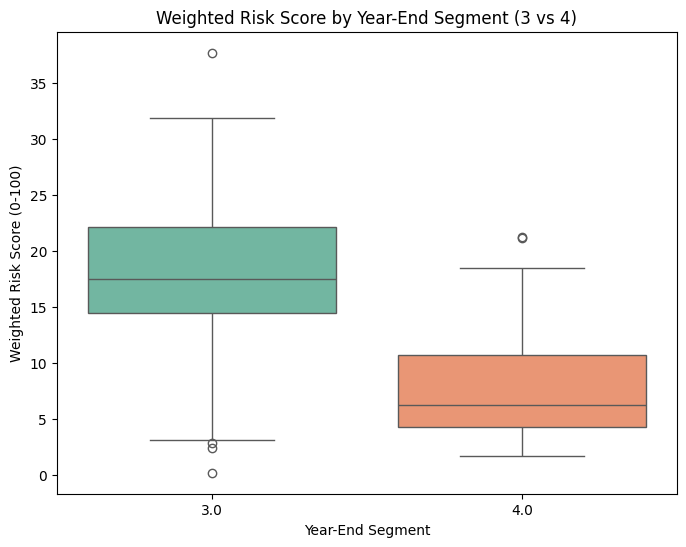


Mann-Whitney U test: Segment 3 > Segment 4
U statistic: 24489.0, p-value: 1.0122204498053214e-14


In [42]:
# Show box-plots of risk scores by segment
import matplotlib.pyplot as plt
test_view_valid = test_view.loc[test_view["segment_yearend"].isin([3, 4])].copy()
plt.figure(figsize=(8, 6))
test_view_valid["segment_yearend_str"] = test_view_valid["segment_yearend"].astype(str)
ax = sns.boxplot(
    data=test_view_valid,
    x="segment_yearend_str",
    y="risk_score_0_100",
    palette="Set2",
)
ax.set_title("Weighted Risk Score by Year-End Segment (3 vs 4)")
ax.set_xlabel("Year-End Segment")
ax.set_ylabel("Weighted Risk Score (0-100)")
plt.show()
# ----------------------------- 
# Mann-Whitney U test to compare distributions
# -----------------------------
from scipy.stats import mannwhitneyu
seg3_scores = test_view_valid.loc[test_view_valid["segment_yearend"] == 3, "risk_score_0_100"]
seg4_scores = test_view_valid.loc[test_view_valid["segment_yearend"] == 4, "risk_score_0_100"]
u_stat, p_value = mannwhitneyu(seg3_scores, seg4_scores, alternative="greater")
print(f"\nMann-Whitney U test: Segment 3 > Segment 4")
print(f"U statistic: {u_stat}, p-value: {p_value}")
# -----------------------------
# END OF CODE                   

In [43]:
# Scenario stress testing
# Compare the average impacts on Segment 3 vs Segment 4 importers
# Scenarios:
#   1) Increase top2 country share by 0.10 (10 percentage points)
#   2) Increase TEU volume by 50%
#   3) Decrease country entropy by 0.5
#   4) Increase port top1 share by 0.15 (15 percentage points)
#   5) Increase TEU volatility CV by 0.2
# Analyze how these changes affect the weighted risk score
# -------------------------------------------------------------------
# --- Replace the contents of Cell 35 (Scenario stress testing) with this ---

import numpy as np
import pandas as pd

# Local predictor to avoid name collisions with later cells
def predict_risk_proba_model1(X_in: pd.DataFrame) -> np.ndarray:
    Xv = X_in[feature_cols].to_numpy(dtype=np.float64, copy=True)
    Xv[~np.isfinite(Xv)] = 0.0
    Xz = scaler.transform(Xv)  # uses Model 1 scaler
    z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
    return _sigmoid(z)

# Scenario stress testing
scenarios = {
    "increase_top2_share_0.10": {"feature": "h1_top2_share", "delta": 0.10},
    # NOTE: for log feature, apply multiplier in raw space then re-log
    "increase_teu_volume_50pct": {"feature": "h1_teu_total_log", "multiplier": 1.5},
    "decrease_country_entropy_0.5": {"feature": "h1_country_entropy", "delta": -0.5},
    "increase_port_top1_share_0.15": {"feature": "h1_port_top1_share", "delta": 0.15},
    "increase_teu_volatility_cv_0.2": {"feature": "h1_teu_volatility_cv", "delta": 0.2},
}

results = []
for scenario_name, params in scenarios.items():
    X_scenario = X_test.copy()
    feature = params["feature"]

    if "delta" in params:
        X_scenario[feature] = X_scenario[feature] + float(params["delta"])
    elif "multiplier" in params:
        mult = float(params["multiplier"])
        if feature.endswith("_log"):
            raw = np.expm1(X_scenario[feature].astype(float))
            raw = (raw * mult).clip(lower=0.0)
            X_scenario[feature] = np.log1p(raw)
        else:
            X_scenario[feature] = X_scenario[feature] * mult
    else:
        continue

    p_scenario = predict_risk_proba_model1(X_scenario)
    risk_score_scenario = 100.0 * p_scenario

    df_compare = pd.DataFrame({
        "importer": data_model.loc[X_test.index, "importer_deduped_name"],
        "segment_yearend": test_view["segment_yearend"],
        "risk_score_baseline": test_view["risk_score_0_100"],
        "risk_score_scenario": risk_score_scenario,
    })
    df_compare["risk_score_change"] = df_compare["risk_score_scenario"] - df_compare["risk_score_baseline"]

    avg_change_seg3 = df_compare.loc[df_compare["segment_yearend"] == 3, "risk_score_change"].mean()
    avg_change_seg4 = df_compare.loc[df_compare["segment_yearend"] == 4, "risk_score_change"].mean()

    results.append({
        "scenario": scenario_name,
        "avg_risk_score_change_seg3": avg_change_seg3,
        "avg_risk_score_change_seg4": avg_change_seg4,
    })

df_results = pd.DataFrame(results)
print("\n=== Scenario Stress Testing Results ===")
display(df_results)

# Mann-Whitney U test for each scenario
from scipy.stats import mannwhitneyu
for scenario_name, params in scenarios.items():
    X_scenario = X_test.copy()
    feature = params["feature"]

    if "delta" in params:
        X_scenario[feature] = X_scenario[feature] + float(params["delta"])
    elif "multiplier" in params:
        mult = float(params["multiplier"])
        if feature.endswith("_log"):
            raw = np.expm1(X_scenario[feature].astype(float))
            raw = (raw * mult).clip(lower=0.0)
            X_scenario[feature] = np.log1p(raw)
        else:
            X_scenario[feature] = X_scenario[feature] * mult
    else:
        continue

    p_scenario = predict_risk_proba_model1(X_scenario)
    risk_score_scenario = 100.0 * p_scenario

    df_compare = pd.DataFrame({
        "importer": data_model.loc[X_test.index, "importer_deduped_name"],
        "segment_yearend": test_view["segment_yearend"],
        "risk_score_baseline": test_view["risk_score_0_100"],
        "risk_score_scenario": risk_score_scenario,
    })
    df_compare["risk_score_change"] = df_compare["risk_score_scenario"] - df_compare["risk_score_baseline"]

    seg3_changes = df_compare.loc[df_compare["segment_yearend"] == 3, "risk_score_change"]
    seg4_changes = df_compare.loc[df_compare["segment_yearend"] == 4, "risk_score_change"]

    u_stat, p_value = mannwhitneyu(seg3_changes, seg4_changes, alternative="greater")

    print(f"\nMann-Whitney U test for scenario '{scenario_name}': Segment 3 > Segment 4")
    print(f"U statistic: {u_stat}, p-value: {p_value}")
# -------------------------------------------------------------------


=== Scenario Stress Testing Results ===


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: divide by zero encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: overflow encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: invalid value encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: divide by zero encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: overflow encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/

,scenario,avg_risk_score_change_seg3,avg_risk_score_change_seg4
0,increase_top2_share_0.10,6.225730,3.260309
1,increase_teu_volume_50pct,0.774969,0.407987
2,decrease_country_entropy_0.5,0.416786,0.211147
3,increase_port_top1_share_0.15,0.000000,0.000000
4,increase_teu_volatility_cv_0.2,1.139445,0.579591



Mann-Whitney U test for scenario 'increase_top2_share_0.10': Segment 3 > Segment 4
U statistic: 24489.0, p-value: 1.0122204498053214e-14

Mann-Whitney U test for scenario 'increase_teu_volume_50pct': Segment 3 > Segment 4
U statistic: 23608.0, p-value: 1.2042298718590572e-12

Mann-Whitney U test for scenario 'decrease_country_entropy_0.5': Segment 3 > Segment 4
U statistic: 24489.0, p-value: 1.0122207873202358e-14

Mann-Whitney U test for scenario 'increase_port_top1_share_0.15': Segment 3 > Segment 4
U statistic: 13968.0, p-value: 1.0

Mann-Whitney U test for scenario 'increase_teu_volatility_cv_0.2': Segment 3 > Segment 4
U statistic: 24489.0, p-value: 1.0122204498053214e-14


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: divide by zero encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: overflow encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: invalid value encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: divide by zero encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/1120895067.py:21: RuntimeWarning: overflow encountered in matmul
  z = b0 + (Xz @ w)          # uses Model 1 intercept + weights
/var/folders/

## Predictive Model 2: Growth/Segment-Upgrade Potential
**Objective:**
Predict which importers are most likely to move into a higher-value segment if volume grows.

This *prediction* directly supports:
* Early-stage M&A
* Growth equity
* Buy-and-build strategies
___
### Operational details:
1. Builds year-end labels for Segment 1, Segment 2, and Segment 3/4.
2. Trains LightGBM “teacher” models:
    * `Seg1` teacher (probability of Segment 1 by year-end)
    * `Seg2` teacher (probability of Segment 2 by year-end)
    * `Seg4_vs_Seg3` teacher (probability of Segment 4 vs Segment 3 among low-volume importers)
3. Distills each teacher into a linear weighted score (same style as your Cell 33 weighted scorer).
4. Produces a balanced table of 20 TEST importers from year-end Segments 3 and 4, showing:
    * For Segment 4 rows: `p_upgrade_to_seg2`
    * For Segment 3 rows: `p_upgrade_to_seg1` and `p_upgrade_to_seg4`

In [44]:
!pip -q install lightgbm scikit-learn scipy

import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

# -----------------------------
# Ensure df exists
# -----------------------------
if "df" not in globals():
    df = clean_import_table

# -----------------------------
# Helpers: segment 3/4 label builder (full-year)
# -----------------------------
def countries_needed_to_reach_threshold(
    data: pd.DataFrame,
    cutoff_month: int = 12,
    threshold: float = 0.80,
    importer_col: str = "importer_deduped_name",
    country_col: str = "country_of_origin",
    teu_col: str = "calculated_teu_numeric",
    month_col: str = "file_month",
) -> pd.DataFrame:
    d = data.loc[data[month_col] <= cutoff_month, [importer_col, country_col, teu_col]].copy()

    ic = (
        d.groupby([importer_col, country_col], as_index=False)[teu_col]
        .sum()
        .rename(columns={teu_col: "teu_ic"})
    )
    totals = (
        ic.groupby(importer_col, as_index=False)["teu_ic"]
        .sum()
        .rename(columns={"teu_ic": "teu_total"})
    )
    ic = ic.merge(totals, on=importer_col, how="left")
    ic["share"] = ic["teu_ic"] / (ic["teu_total"] + 1e-9)

    ic = ic.sort_values([importer_col, "share"], ascending=[True, False])
    ic["cum_share"] = ic.groupby(importer_col)["share"].cumsum()
    ic["rank"] = ic.groupby(importer_col).cumcount() + 1

    k = (
        ic.loc[ic["cum_share"] >= threshold]
        .groupby(importer_col, as_index=False)["rank"]
        .min()
        .rename(columns={"rank": f"countries_to_{int(threshold*100)}"})
    )

    return totals.merge(k, on=importer_col, how="left")

# -----------------------------
# Build year-end labels
# -----------------------------
year_feats = importer_risk_features(df, cutoff_month=12, prefix="y_")
year_feats["is_segment1"] = ((year_feats["y_teu_total"] >= 200) & (year_feats["y_top2_share"] >= 0.80)).astype(int)
year_feats["is_segment2"] = ((year_feats["y_teu_total"] >= 200) & (year_feats["y_top2_share"] < 0.80)).astype(int)

seg34 = countries_needed_to_reach_threshold(df, cutoff_month=12, threshold=0.80)
VOLUME_THRESHOLD = 200
LOW_DIV_COUNTRIES = 3

seg34["segment_yearend"] = np.select(
    condlist=[
        (seg34["teu_total"] < VOLUME_THRESHOLD) & (seg34["countries_to_80"] <= LOW_DIV_COUNTRIES),
        (seg34["teu_total"] < VOLUME_THRESHOLD) & (seg34["countries_to_80"] > LOW_DIV_COUNTRIES),
    ],
    choicelist=[3, 4],
    default=np.nan,
)

# -----------------------------
# Build H1 features + assemble modeling table
# -----------------------------
h1_feats = importer_risk_features(df, cutoff_month=6, prefix="h1_")

data_all = (
    h1_feats
    .merge(year_feats[["importer_deduped_name", "is_segment1", "is_segment2"]], on="importer_deduped_name", how="inner")
    .merge(seg34[["importer_deduped_name", "teu_total", "countries_to_80", "segment_yearend"]], on="importer_deduped_name", how="left")
)

feature_cols = [
    "h1_teu_total_log",
    "h1_num_countries",
    "h1_top1_share",
    "h1_top2_share",
    "h1_country_entropy",
    "h1_hs_top2_share",
    "h1_port_top1_share",
    "h1_teu_volatility_cv",
    "h1_num_hs",
    "h1_num_ports",
]

X = data_all[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# One global split (so we can sample "TEST importers" consistently)
X_train, X_temp, idx_train, idx_temp = train_test_split(
    X.index, X.index, test_size=0.30, random_state=1234
)
# Convert index-only split into actual frames
X_train = X.loc[X_train]
X_temp = X.loc[X_temp]

X_val_idx, X_test_idx = train_test_split(X_temp.index, test_size=0.50, random_state=1234)
X_val = X.loc[X_val_idx]
X_test = X.loc[X_test_idx]

print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

# -----------------------------
# Train LightGBM helper
# -----------------------------
def train_lgbm_binary(Xtr, ytr, Xva, yva, seed=1234):
    pos = int(ytr.sum())
    neg = int(len(ytr) - pos)
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    lgb_train = lgb.Dataset(Xtr, label=ytr)
    lgb_val = lgb.Dataset(Xva, label=yva, reference=lgb_train)

    params = {
        "objective": "binary",
        "boosting_type": "gbdt",
        "metric": ["auc", "average_precision"],
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "scale_pos_weight": scale_pos_weight,
        "seed": seed,
        "verbosity": -1,
    }

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=5000,
        valid_sets=[lgb_train, lgb_val],
        valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
    )
    return model

# -----------------------------
# Distill to linear mimic (same idea as earlier)
# -----------------------------
def _sigmoid(z):
    z = np.clip(z, -35, 35)
    return 1.0 / (1.0 + np.exp(-z))

def _logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def fit_monotonic_linear_mimic(X_distill: pd.DataFrame, p_teacher: np.ndarray, feature_sign: dict, alpha=2.0, maxiter=5000, max_abs_beta=25.0):
    cols = list(X_distill.columns)
    X_raw = X_distill[cols].to_numpy(dtype=np.float64, copy=True)
    p_teacher = np.asarray(p_teacher, dtype=np.float64)

    good = np.isfinite(X_raw).all(axis=1) & np.isfinite(p_teacher)
    X_raw = X_raw[good]
    p_teacher = p_teacher[good]

    scaler = StandardScaler()
    Xz = scaler.fit_transform(X_raw)

    t = _logit(p_teacher)
    d = Xz.shape[1]

    bounds = []
    for c in cols:
        s = feature_sign.get(c, 0)
        if s > 0:
            bounds.append((0.0, max_abs_beta))
        elif s < 0:
            bounds.append((-max_abs_beta, 0.0))
        else:
            bounds.append((-max_abs_beta, max_abs_beta))
    bounds.append((-50.0, 50.0))  # intercept

    x0 = np.zeros(d + 1, dtype=np.float64)
    x0[-1] = float(np.mean(t))
    n = float(Xz.shape[0])

    def obj_and_grad(x):
        beta = x[:d]
        b0 = x[-1]
        yhat = b0 + (Xz @ beta)
        r = (yhat - t)
        loss = (r @ r) / n + alpha * (beta @ beta)
        grad_beta = (2.0 / n) * (Xz.T @ r) + 2.0 * alpha * beta
        grad_b0 = (2.0 / n) * np.sum(r)
        grad = np.concatenate([grad_beta, np.array([grad_b0])])
        return loss, grad

    res = minimize(
        fun=lambda x: obj_and_grad(x)[0],
        x0=x0,
        jac=lambda x: obj_and_grad(x)[1],
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": maxiter},
    )

    beta = res.x[:d]
    b0 = res.x[-1]

    # Convert z-space coefficients back to raw space (for weight extraction)
    means = scaler.mean_
    stds = scaler.scale_
    w_raw = beta / (stds + 1e-12)
    intercept_raw = b0 - np.sum((means / (stds + 1e-12)) * beta)

    coef_raw = pd.Series(w_raw, index=cols).sort_values(key=lambda s: np.abs(s), ascending=False)

    return {"coef_raw": coef_raw, "intercept_raw": float(intercept_raw), "opt_result": res}

def build_weighted_scorer_from_teacher(Xtr: pd.DataFrame, p_teacher_tr: np.ndarray, feature_sign: dict):
    mimic = fit_monotonic_linear_mimic(Xtr, p_teacher_tr, feature_sign=feature_sign, alpha=2.0)

    absw = mimic["coef_raw"].abs()
    weights_linear = (absw / (absw.sum() + 1e-12)).to_dict()

    scaler = StandardScaler()
    scaler.fit(Xtr[feature_cols].to_numpy(dtype=np.float64, copy=True))

    w = np.array(
        [float(weights_linear[c]) * (1.0 if feature_sign.get(c, +1) >= 0 else -1.0) for c in feature_cols],
        dtype=np.float64,
    )

    return {"weights_linear": weights_linear, "scaler": scaler, "w": w}

def predict_weighted_proba(X_in: pd.DataFrame, scorer: dict, base_rate: float):
    b0 = float(_logit(base_rate))
    Xv = X_in[feature_cols].to_numpy(dtype=np.float64, copy=True)
    Xv[~np.isfinite(Xv)] = 0.0
    Xz = scorer["scaler"].transform(Xv)
    z = b0 + (Xz @ scorer["w"])
    return _sigmoid(z)

# -----------------------------
# 1) Segment 1 teacher + linear mimic scorer
# -----------------------------
y_seg1_train = data_all.loc[X_train.index, "is_segment1"].astype(int)
y_seg1_val = data_all.loc[X_val.index, "is_segment1"].astype(int)

gbm_seg1 = train_lgbm_binary(X_train, y_seg1_train, X_val, y_seg1_val)
p_teacher_seg1_train = gbm_seg1.predict(X_train, num_iteration=gbm_seg1.best_iteration)

feature_sign_seg1 = {
    "h1_teu_total_log": +1,
    "h1_num_countries": -1,
    "h1_top1_share": +1,
    "h1_top2_share": +1,
    "h1_country_entropy": -1,
    "h1_hs_top2_share": +1,
    "h1_port_top1_share": +1,
    "h1_teu_volatility_cv": +1,
    "h1_num_hs": -1,
    "h1_num_ports": -1,
}
scorer_seg1 = build_weighted_scorer_from_teacher(X_train, p_teacher_seg1_train, feature_sign_seg1)

# -----------------------------
# 2) Segment 2 teacher + linear mimic scorer (upgrade target for Segment 4)
# -----------------------------
y_seg2_train = data_all.loc[X_train.index, "is_segment2"].astype(int)
y_seg2_val = data_all.loc[X_val.index, "is_segment2"].astype(int)

gbm_seg2 = train_lgbm_binary(X_train, y_seg2_train, X_val, y_seg2_val)
p_teacher_seg2_train = gbm_seg2.predict(X_train, num_iteration=gbm_seg2.best_iteration)

# Signs: Segment 2 is "high volume AND diversified", so top2_share tends to *decrease* seg2 probability.
feature_sign_seg2 = {
    "h1_teu_total_log": +1,
    "h1_num_countries": +1,
    "h1_top1_share": -1,
    "h1_top2_share": -1,
    "h1_country_entropy": +1,
    "h1_hs_top2_share": -1,
    "h1_port_top1_share": -1,
    "h1_teu_volatility_cv": 0,
    "h1_num_hs": +1,
    "h1_num_ports": +1,
}
scorer_seg2 = build_weighted_scorer_from_teacher(X_train, p_teacher_seg2_train, feature_sign_seg2)

# -----------------------------
# 3) Segment 4 vs Segment 3 teacher + linear mimic scorer (upgrade target for Segment 3 -> Segment 4)
#    Train ONLY on low-volume importers where segment_yearend is 3 or 4.
# -----------------------------
train_low = data_all.loc[X_train.index].query("segment_yearend in [3, 4]").index
val_low = data_all.loc[X_val.index].query("segment_yearend in [3, 4]").index

X_train_low = X.loc[train_low]
X_val_low = X.loc[val_low]

y_seg4_train = (data_all.loc[train_low, "segment_yearend"] == 4).astype(int)
y_seg4_val = (data_all.loc[val_low, "segment_yearend"] == 4).astype(int)

gbm_seg4 = train_lgbm_binary(X_train_low, y_seg4_train, X_val_low, y_seg4_val)
p_teacher_seg4_train = gbm_seg4.predict(X_train_low, num_iteration=gbm_seg4.best_iteration)

# Signs: Segment 4 is "more diversified than Segment 3"
feature_sign_seg4 = {
    "h1_teu_total_log": 0,
    "h1_num_countries": +1,
    "h1_top1_share": -1,
    "h1_top2_share": -1,
    "h1_country_entropy": +1,
    "h1_hs_top2_share": 0,
    "h1_port_top1_share": 0,
    "h1_teu_volatility_cv": 0,
    "h1_num_hs": +1,
    "h1_num_ports": +1,
}
scorer_seg4 = build_weighted_scorer_from_teacher(X_train_low, p_teacher_seg4_train, feature_sign_seg4)

# -----------------------------
# Predict upgrade probabilities on TEST
# -----------------------------
p_seg1_test = predict_weighted_proba(X_test, scorer_seg1, base_rate=float(y_seg1_train.mean()))
p_seg2_test = predict_weighted_proba(X_test, scorer_seg2, base_rate=float(y_seg2_train.mean()))

# For seg4-vs-seg3 scorer, we can still compute on all X_test (scaler/weights exist);
# interpret as "probability of being Segment 4 (vs Segment 3) within low-volume regime".
p_seg4_test = predict_weighted_proba(X_test, scorer_seg4, base_rate=float(y_seg4_train.mean()))

# -----------------------------
# Build view + balanced sample of 20 from year-end Segments 3 and 4 (TEST only)
# -----------------------------
test_view = data_all.loc[X_test.index, [
    "importer_deduped_name",
    "segment_yearend",
    "teu_total",
    "countries_to_80",
    "is_segment1",
    "is_segment2",
]].copy()

test_view["p_upgrade_to_seg1"] = p_seg1_test
test_view["p_upgrade_to_seg2"] = p_seg2_test
test_view["p_upgrade_to_seg4"] = p_seg4_test

# Keep only Seg 3/4 (as requested)
test_34 = test_view.loc[test_view["segment_yearend"].isin([3, 4])].copy()

seg3 = test_34.loc[test_34["segment_yearend"] == 3]
seg4 = test_34.loc[test_34["segment_yearend"] == 4]

n_each = min(10, len(seg3), len(seg4))
if n_each == 0:
    print("No balanced Segment 3/4 samples available in the TEST split (one of the segments is empty).")
else:
    sample = (
        pd.concat(
            [seg3.sample(n=n_each, random_state=1234), seg4.sample(n=n_each, random_state=1234)],
            axis=0,
        )
        .sample(frac=1.0, random_state=1234)
        .reset_index(drop=True)
    )

    # “Applicability” columns: keep numeric values, but we'll format for display (no NaN shown)
    sample["p_upgrade_to_seg2_applicable"] = np.where(
        sample["segment_yearend"] == 4, sample["p_upgrade_to_seg2"], np.nan
    )
    sample["p_upgrade_to_seg1_applicable"] = np.where(
        sample["segment_yearend"] == 3, sample["p_upgrade_to_seg1"], np.nan
    )
    sample["p_upgrade_to_seg4_applicable"] = np.where(
        sample["segment_yearend"] == 3, sample["p_upgrade_to_seg4"], np.nan
    )

    cols_show = [
        "importer_deduped_name",
        "segment_yearend",
        "teu_total",
        "countries_to_80",
        "p_upgrade_to_seg2_applicable",  # Segment 4 -> Segment 2
        "p_upgrade_to_seg1_applicable",  # Segment 3 -> Segment 1
        "p_upgrade_to_seg4_applicable",  # Segment 3 -> Segment 4
    ]

    print(f"\n=== Balanced TEST sample (Segments 3 & 4): n_each={n_each}, total={2*n_each} ===")

    # Display-only: format probs and hide NaN (show blank instead)
    display_df = sample[cols_show].copy()
    prob_cols = [
        "p_upgrade_to_seg2_applicable",
        "p_upgrade_to_seg1_applicable",
        "p_upgrade_to_seg4_applicable",
    ]
    for c in prob_cols:
        display_df[c] = display_df[c].map(lambda v: "" if pd.isna(v) else f"{float(v):.1%}")

    display(display_df)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Split sizes: train=4805, val=1030, test=1030
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[5]	train's auc: 0.978442	train's average_precision: 0.921935	val's auc: 0.960061	val's average_precision: 0.8746
Training until validation scores don't improve for 100 rounds


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: divide by zero encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: overflow encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: invalid value encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: divide by zero encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: overflow encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: invalid value encountered in matmul
  loss = (r @ r) / n + a

Early stopping, best iteration is:
[3]	train's auc: 0.985673	train's average_precision: 0.786789	val's auc: 0.983888	val's average_precision: 0.839157
Training until validation scores don't improve for 100 rounds


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: divide by zero encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: overflow encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: invalid value encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: divide by zero encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: overflow encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: invalid value encountered in matmul
  loss = (r @ r) / n + a

Early stopping, best iteration is:
[14]	train's auc: 0.98111	train's average_precision: 0.734674	val's auc: 0.935276	val's average_precision: 0.478532

=== Balanced TEST sample (Segments 3 & 4): n_each=10, total=20 ===


/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: divide by zero encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: overflow encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:197: RuntimeWarning: invalid value encountered in matmul
  yhat = b0 + (Xz @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: divide by zero encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: overflow encountered in matmul
  loss = (r @ r) / n + alpha * (beta @ beta)
/var/folders/x_/lv7v74f13hb1d9l5hxnf_wtr0000gp/T/ipykernel_60340/4277913277.py:199: RuntimeWarning: invalid value encountered in matmul
  loss = (r @ r) / n + a

,importer_deduped_name,segment_yearend,teu_total,countries_to_80,p_upgrade_to_seg2_applicable,p_upgrade_to_seg1_applicable,p_upgrade_to_seg4_applicable
0,KHEE TRADING INC,3.0,9.000000,3.0,,15.8%,3.7%
1,RUSSELL A. FARROW (U.S.) INC,4.0,59.000000,4.0,21.2%,,
2,HM SUREROCK INC,3.0,112.000000,1.0,,28.3%,2.8%
3,T. ELENTENY IMPORTS,4.0,83.897471,4.0,20.2%,,
4,USA WINE WEST,4.0,120.841076,4.0,30.0%,,
5,XIAMEN PORT TRADING COMPANY LTD,3.0,8.000000,1.0,,18.1%,2.7%
6,CEMEX,3.0,4.345100,2.0,,20.4%,3.8%
7,STONE BASYX,3.0,76.000000,3.0,,6.9%,21.0%
8,WORLDWISE INC,3.0,113.000000,2.0,,12.4%,10.4%
9,INDO-EUROPEAN FOODS INC,4.0,73.000000,5.0,30.3%,,


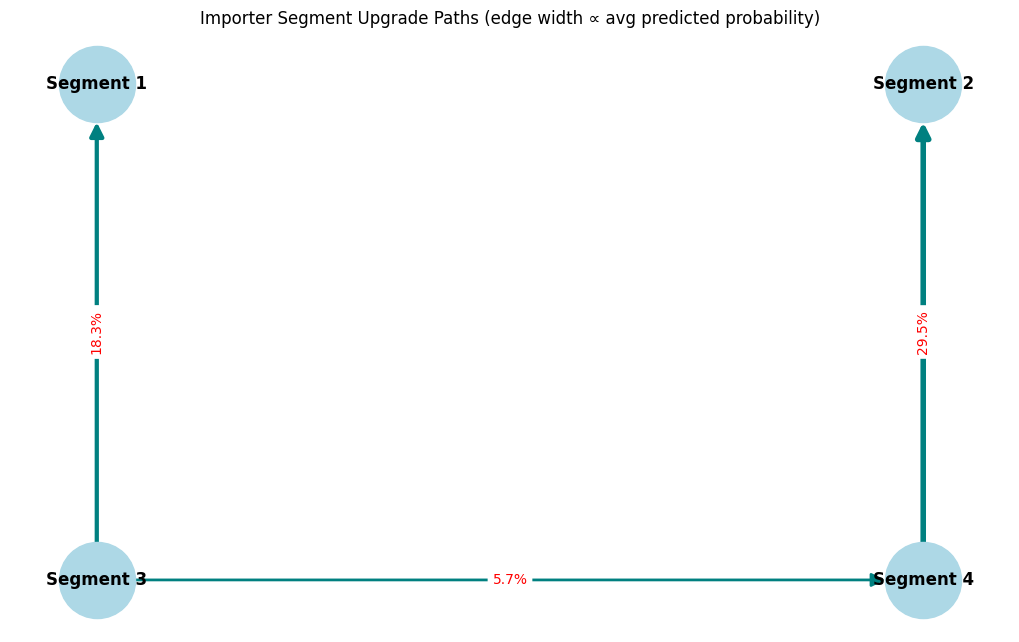

In [45]:
# Visualize a Petri-net like graph of the upgrade paths
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Expecting Cell 36 to have created `test_view` with:
#   - segment_yearend in {3,4}
#   - p_upgrade_to_seg1, p_upgrade_to_seg4, p_upgrade_to_seg2
if "test_view" not in globals():
    raise NameError("`test_view` not found. Run Cell 36 first to compute upgrade probabilities.")

tv = test_view.copy()

# Compute average probabilities by applicable segment
p_31 = float(tv.loc[tv["segment_yearend"] == 3, "p_upgrade_to_seg1"].mean())
p_34 = float(tv.loc[tv["segment_yearend"] == 3, "p_upgrade_to_seg4"].mean())
p_42 = float(tv.loc[tv["segment_yearend"] == 4, "p_upgrade_to_seg2"].mean())

# Handle NaNs defensively (e.g., if a segment is absent in the test split)
p_31 = 0.0 if not np.isfinite(p_31) else p_31
p_34 = 0.0 if not np.isfinite(p_34) else p_34
p_42 = 0.0 if not np.isfinite(p_42) else p_42

# Build graph with probs on edges
G = nx.DiGraph()
G.add_edge("Segment 3", "Segment 1", prob=p_31)
G.add_edge("Segment 3", "Segment 4", prob=p_34)
G.add_edge("Segment 4", "Segment 2", prob=p_42)

# Layout (same as before)
pos = {
    "Segment 1": (0, 0),
    "Segment 2": (2, 0),
    "Segment 3": (0, -2),
    "Segment 4": (2, -2),
}

# Arrow thickness proportional to avg probability
min_w, max_w = 1.5, 10.0
edge_probs = [G.edges[e]["prob"] for e in G.edges()]
edge_widths = [min_w + float(p) * (max_w - min_w) for p in edge_probs]

# Edge labels show avg probability (replacing prior text labels)
edge_labels = {e: f"{G.edges[e]['prob']:.1%}" for e in G.edges()}

plt.figure(figsize=(10, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=12,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
    width=edge_widths,
    edge_color="teal",
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_color="red",
    font_size=10,
    label_pos=0.5,
)

plt.title("Importer Segment Upgrade Paths (edge width ∝ avg predicted probability)")
plt.axis("off")
plt.show()

In [46]:
# Bootstrap evaluation of upgrade probabilities
# All transitions are from low-volume importers only (Segments 3 and 4)
# -------------------------------------------------------------------
import numpy as np  
import pandas as pd
from sklearn.utils import resample
# Expecting Cell 36 to have created `test_view` with:
#   - segment_yearend in {3,4}
#   - p_upgrade_to_seg1, p_upgrade_to_seg4, p_upgrade_to_seg2
# -------------------------------------------------------------------
if "test_view" not in globals():
    raise NameError("`test_view` not found. Run Cell 36 first to compute upgrade probabilities.")   
tv = test_view.copy()
tv_low = tv.loc[tv["segment_yearend"].isin([3, 4])].copy()
n_bootstrap = 1000
results = []
for i in range(n_bootstrap):
    sample = resample(tv_low, replace=True, n_samples=len(tv_low), random_state=1234 + i)
    seg3 = sample.loc[sample["segment_yearend"] == 3]
    seg4 = sample.loc[sample["segment_yearend"] == 4]

    p_31 = float(seg3["p_upgrade_to_seg1"].mean()) if len(seg3) > 0 else np.nan
    p_34 = float(seg3["p_upgrade_to_seg4"].mean()) if len(seg3) > 0 else np.nan
    p_42 = float(seg4["p_upgrade_to_seg2"].mean()) if len(seg4) > 0 else np.nan

    results.append({
        "p_31": p_31,
        "p_34": p_34,
        "p_42": p_42,
    })
df_boot = pd.DataFrame(results)
def summarize_bootstrap(df: pd.DataFrame, col: str):
    mean = df[col].mean()
    lower = df[col].quantile(0.025)
    upper = df[col].quantile(0.975)
    return mean, lower, upper
summary = {}
for col in ["p_31", "p_34", "p_42"]:
    mean, lower, upper = summarize_bootstrap(df_boot, col)
    summary[col] = {
        "mean": mean,
        "95ci_lower": lower,
        "95ci_upper": upper,
    }
print("\n=== Bootstrap Summary of Upgrade Probabilities (Segments 3 & 4) ===")
for col, stats in summary.items():
    print(f"{col}: mean={stats['mean']:.4f}, 95% CI=({stats['95ci_lower']:.4f}, {stats['95ci_upper']:.4f})")
# -----------------------------



=== Bootstrap Summary of Upgrade Probabilities (Segments 3 & 4) ===
p_31: mean=0.1829, 95% CI=(0.1789, 0.1869)
p_34: mean=0.0573, 95% CI=(0.0528, 0.0622)
p_42: mean=0.2938, 95% CI=(0.2390, 0.3486)


(c) Drandreb Earl Juanico

In [59]:
# Calculate the Total TEU contributed by companies without country_of_origin data and the percentage of total TEU they represent
# Use clean_import_table as df if not already defined
if "df" not in globals():
    df = clean_import_table
teu_no_country = df.loc[df["country_of_origin"].isna(), "calculated_teu_numeric"].sum()
teu_total = df["calculated_teu_numeric"].sum()
percentage_no_country = (teu_no_country / teu_total) * 100 if teu_total > 0 else 0.0
print(f"Total TEU with no country_of_origin: {teu_no_country:.2f}")
print(f"Percentage of total TEU with no country_of_origin: {percentage_no_country:.2e}%")
# Count how many companies have missing country_of_origin data
num_companies_no_country = df["country_of_origin"].isna().sum()
print(f"Number of companies with missing country_of_origin: {num_companies_no_country}")

Total TEU with no country_of_origin: 4.00
Percentage of total TEU with no country_of_origin: 7.43e-05%
Number of companies with missing country_of_origin: 3


In [63]:
#Calculate the Total TEU of companies with not more than 200 TEU and the percentage of total TEU they represent
# Use clean_import_table as df if not already defined
# The basis is teu_total per company, so we need to aggregate first

if "df" not in globals():
    df = clean_import_table

teu_by_company = df.groupby("importer_deduped_name")["calculated_teu_numeric"].sum().reset_index()
teu_low_volume = teu_by_company.loc[teu_by_company["calculated_teu_numeric"] <= 200, "calculated_teu_numeric"].sum()
teu_total = teu_by_company["calculated_teu_numeric"].sum()
percentage_low_volume = (teu_low_volume / teu_total) * 100 if teu_total > 0 else 0.0
print(f"Total TEU of companies with not more than 200 TEU: {teu_low_volume:.2f}")
print(f"Percentage of total TEU from companies with not more than 200 TEU: {percentage_low_volume:.2e}%")

# How many importers contribute a teu_total of 200 or less? What percentage of total importers does this represent?
num_importers_low_volume = teu_by_company.loc[teu_by_company["calculated_teu_numeric"] <= 200, "importer_deduped_name"].nunique()
total_importers = teu_by_company["importer_deduped_name"].nunique()
percentage_importers_low_volume = (num_importers_low_volume / total_importers) * 100 if total_importers > 0 else 0.0
print(f"Number of importers with total TEU of 200 or less: {num_importers_low_volume}")
print(f"Percentage of total importers with total TEU of 200 or less: {percentage_importers_low_volume:.2f}%")


Total TEU of companies with not more than 200 TEU: 307785.55
Percentage of total TEU from companies with not more than 200 TEU: 1.76e+01%
Number of importers with total TEU of 200 or less: 6327
Percentage of total importers with total TEU of 200 or less: 80.62%


In [64]:
# Calculate the Total TEU of companies with more than 200 TEU and the percentage of total TEU they represent
# Use clean_import_table as df if not already defined
# The basis is teu_total per company, so we need to aggregate first
if "df" not in globals():
    df = clean_import_table
teu_by_company = df.groupby("importer_deduped_name")["calculated_teu_numeric"].sum().reset_index()
teu_high_volume = teu_by_company.loc[teu_by_company["calculated_teu_numeric"] > 200, "calculated_teu_numeric"].sum()
teu_total = teu_by_company["calculated_teu_numeric"].sum()
percentage_high_volume = (teu_high_volume / teu_total) * 100 if teu_total > 0 else 0.0
print(f"Total TEU of companies with more than 200 TEU: {teu_high_volume:.2f}")
print(f"Percentage of total TEU from companies with more than 200 TEU: {percentage_high_volume:.2e}%")
# How many importers contribute a teu_total of more than 200? What percentage of total importers does this represent?
num_importers_high_volume = teu_by_company.loc[teu_by_company["calculated_teu_numeric"] > 200, "importer_deduped_name"].nunique()
total_importers = teu_by_company["importer_deduped_name"].nunique()
percentage_importers_high_volume = (num_importers_high_volume / total_importers)* 100 if total_importers > 0 else 0.0
print(f"Number of importers with total TEU of more than 200: {num_importers_high_volume}")
print(f"Percentage of total importers with total TEU of more than 200: {percentage_importers_high_volume:.2f}%")


Total TEU of companies with more than 200 TEU: 1436630.89
Percentage of total TEU from companies with more than 200 TEU: 8.24e+01%
Number of importers with total TEU of more than 200: 1521
Percentage of total importers with total TEU of more than 200: 19.38%
